<a href="https://colab.research.google.com/github/srishanthdevoju/Celebal_Internship/blob/main/week2_srishanthdevoju.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 Tesla EV Deliveries & Production — End-to-End ML Pipeline


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tesla-ea-deliveries-and-production-data20152025' dataset.
Path to dataset files: /kaggle/input/tesla-ea-deliveries-and-production-data20152025


In [3]:
import os
os.listdir(path)

['tesla_deliveries_dataset_2015_2025.csv']

In [4]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(file_path)
    print(f"Loaded file: {csv_files[0]}")
else:
    print("No CSV files found in the dataset directory.")

Loaded file: tesla_deliveries_dataset_2015_2025.csv


In [5]:
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [6]:
print(f'Dataset Shape: {df.shape}') #shape
print(f'Total Records: {df.size}') #size
print(f'Total Number of Rows: {df.shape[0]}') #rows
print(f'Total Number of Columns: {df.shape[1]}') #columns

Dataset Shape: (2640, 12)
Total Records: 31680
Total Number of Rows: 2640
Total Number of Columns: 12


In [7]:
print('Dataset info:\n')
df.info()

Dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [8]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [9]:
#Missing values

print('Missing Values:')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing,'Percentage (%)': missing_pct})
missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else print("No missing values found!")
print(f'\n Total missing values: {missing.sum()}')


Missing Values:
No missing values found!

 Total missing values: 0


In [10]:
#Duplicates handling

duplicates = df.duplicated().sum()
print(f'Duplicated Rows: {duplicates}')
if duplicates >0:
  print(f'Removing {duplicates} duplicated rows...')
  df.drop_duplicates(inplace=True)
  print(f'Duplicated Rows: {df.duplicated().sum()}')
else:
  print('No duplicates found!')

Duplicated Rows: 0
No duplicates found!


In [11]:
#data types and unique values
for col in df.columns:
  print(f'{col:30s}  | dtype: {str(df[col].dtype):10s} | unique: {df[col].nunique():6d} | nulls: {df[col].isnull().sum()}")')

Year                            | dtype: int64      | unique:     11 | nulls: 0")
Month                           | dtype: int64      | unique:     12 | nulls: 0")
Region                          | dtype: object     | unique:      4 | nulls: 0")
Model                           | dtype: object     | unique:      5 | nulls: 0")
Estimated_Deliveries            | dtype: int64      | unique:   2401 | nulls: 0")
Production_Units                | dtype: int64      | unique:   2430 | nulls: 0")
Avg_Price_USD                   | dtype: float64    | unique:   2638 | nulls: 0")
Battery_Capacity_kWh            | dtype: int64      | unique:      5 | nulls: 0")
Range_km                        | dtype: int64      | unique:    219 | nulls: 0")
CO2_Saved_tons                  | dtype: float64    | unique:   2599 | nulls: 0")
Source_Type                     | dtype: object     | unique:      3 | nulls: 0")
Charging_Stations               | dtype: int64      | unique:   2389 | nulls: 0")


## Data Preprocessing & Cleaning

In [12]:
data = df.copy()
print('Current Data Types :')
print(data.dtypes)
print()

Current Data Types :
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object



In [13]:
#Numeric columns
numeric_cols =['Year','Month','Estimated_Deliveries','Production_Units','Avg_Price_USD',
               'Battery_Capacity_kWh', 'Range_km','CO2_Saved_tons', 'Charging_Stations']
for col in numeric_cols:
  data[col] = pd.to_numeric(data[col], errors='coerce')


#check catergorical columns
cat_cols =['Region','Model','Source_Type']
for col in cat_cols:
  print(f'\n{col} : {data[col].unique()}')



Region : ['Europe' 'Asia' 'North America' 'Middle East']

Model : ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']

Source_Type : ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


In [14]:
#Handle any remaining missing values if any exists

if data.isnull().sum().sum() >0:
  print('Handling missing values')
  #fill with median
  for col in numeric_cols:
    if data[col].isnull().sum() >0:
      data[col].fillna(data[col].median(), inplace=True)
  for col in cat_cols:
    #fill with mode
    if data[col].isnull().sum() >0:
      data[col].fillna(data[col].mode()[0], inplace=True)
else:
  print('No missing values found!')

No missing values found!


In [15]:
#outlier detection

outlier_info = {}
for col in numeric_cols:
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = ((data[col]<lower_bound) | (data[col]>upper_bound))
  outlier_info[col] = outliers
  if outliers.sum() > 0 :
    print(f'{col} has {outliers.sum()} outliers')
print(f"\nTotal outlier instances: {sum(outlier_info.values())}")
print("Note: We keep outliers as they represent real-world variation in Tesla's data.")


Estimated_Deliveries has 12 outliers
Production_Units has 12 outliers
CO2_Saved_tons has 45 outliers

Total outlier instances: 0       1
1       0
2       0
3       0
4       0
       ..
2635    0
2636    0
2637    0
2638    0
2639    0
Length: 2640, dtype: int64
Note: We keep outliers as they represent real-world variation in Tesla's data.


##  Exploratory Data Analysis (EDA)

In [16]:
import os

os.makedirs("distribution_plots", exist_ok=True)

for idx, col in enumerate(numeric_cols):
    plt.figure(figsize=(8, 6))

    plt.hist(
        data[col],
        bins=40,
        color=plt.cm.viridis(idx / len(numeric_cols)),
        edgecolor='white',
        alpha=0.8
    )

    plt.title(f'Distribution of {col}')
    plt.axvline(data[col].mean(), color='red', linestyle='--')
    plt.axvline(data[col].median(), color='orange', linestyle='-.')

    plt.tight_layout()

    plt.savefig(
        f"distribution_plots/{col}_distribution.png",
        dpi=150,
        bbox_inches='tight'
    )

    plt.close()

### Correlation Analysis

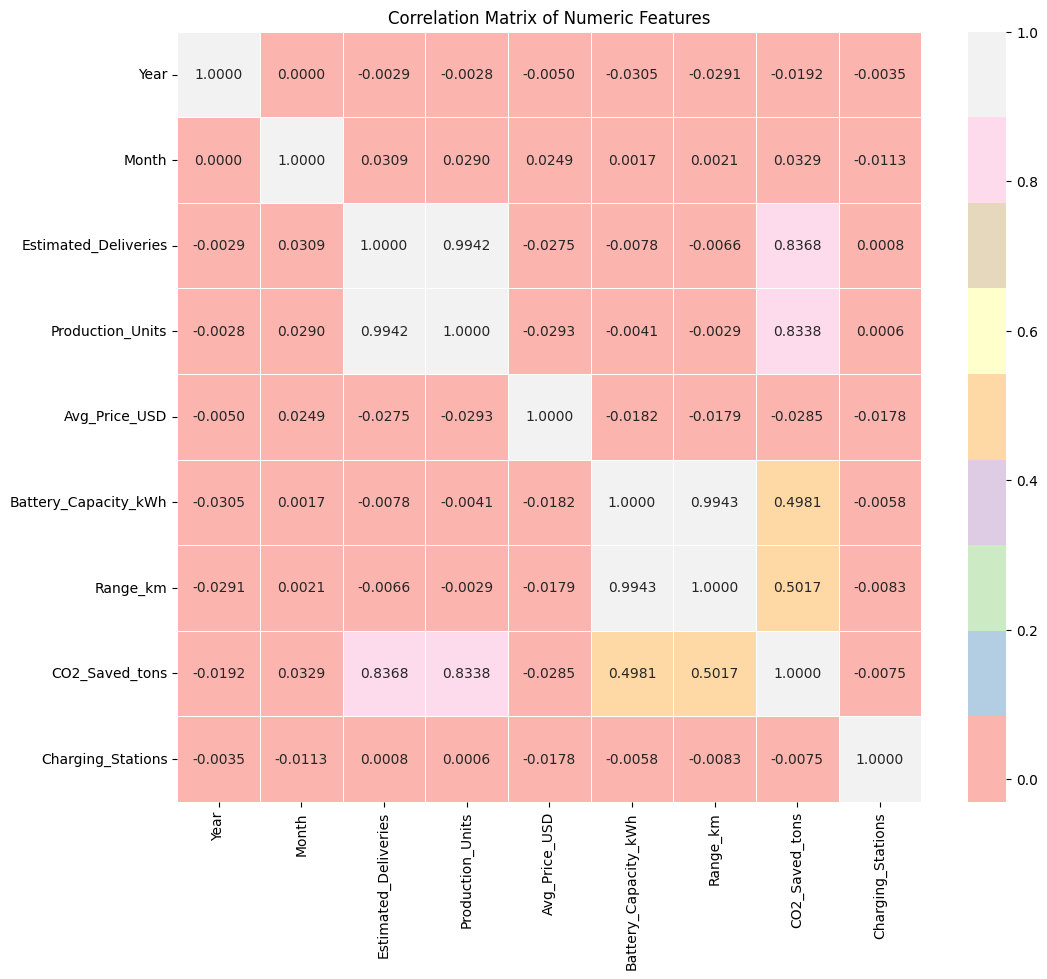

In [17]:
correlation_matrix = data[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='Pastel1', fmt='.4f', linewidths=.5)
plt.title('Correlation Matrix of Numeric Features')
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
#top correlations with estimated deliveries
print('Top correlations with estimated deliveries')

target_corr= correlation_matrix['Estimated_Deliveries'].drop('Estimated_Deliveries').sort_values(ascending=False)
print(target_corr.head(5))

Top correlations with estimated deliveries
Production_Units     0.994234
CO2_Saved_tons       0.836814
Month                0.030877
Charging_Stations    0.000753
Year                -0.002863
Name: Estimated_Deliveries, dtype: float64


### Categorical Analysis

In [19]:
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    display(data[col].value_counts().reset_index())



Value counts for Region:


,Region,count
0,Europe,660
1,Asia,660
2,North America,660
3,Middle East,660



Value counts for Model:


,Model,count
0,Model S,528
1,Model X,528
2,Model 3,528
3,Model Y,528
4,Cybertruck,528



Value counts for Source_Type:


,Source_Type,count
0,Interpolated (Month),884
1,Official (Quarter),884
2,Estimated (Region),872


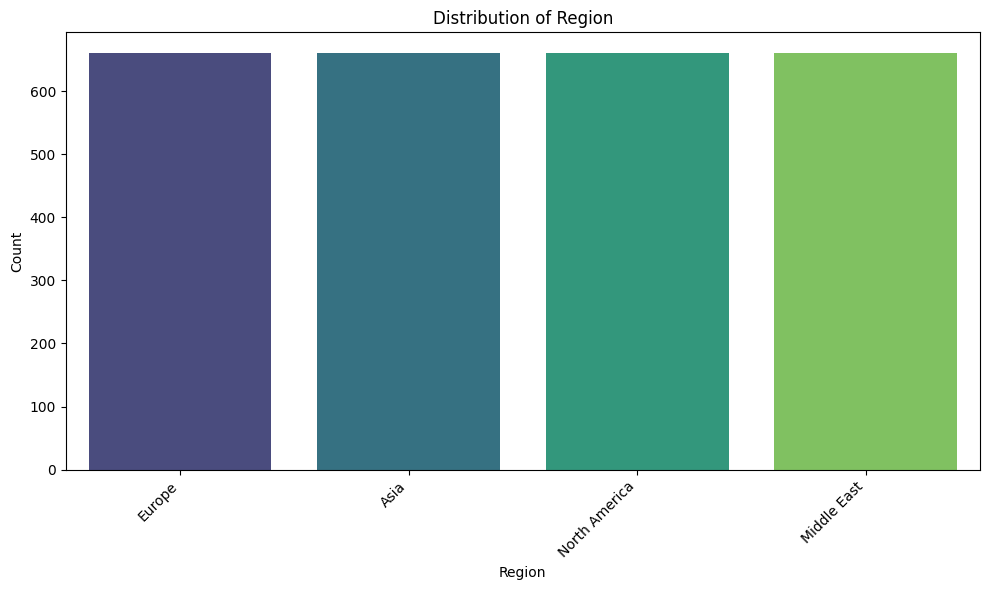

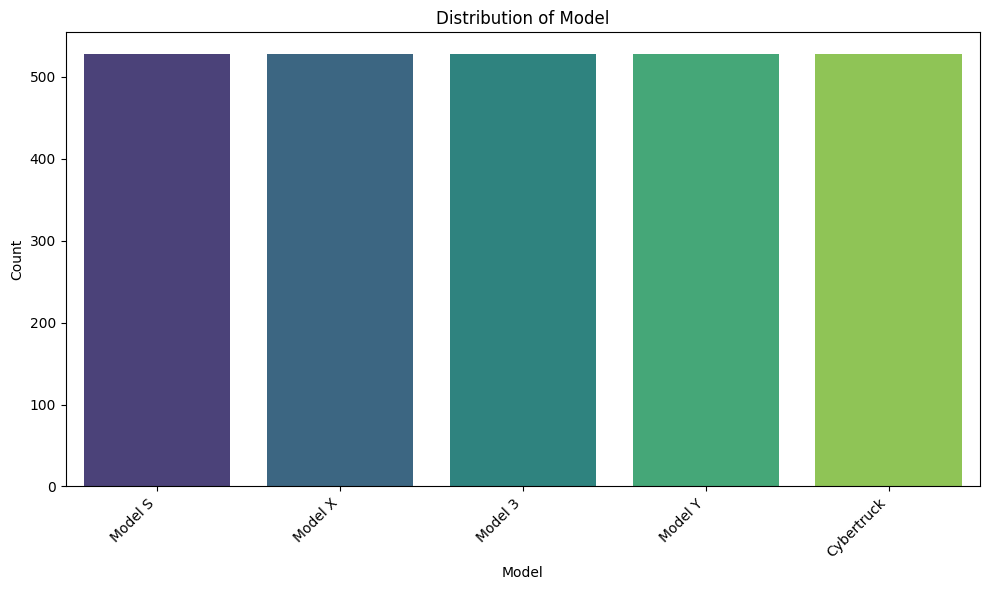

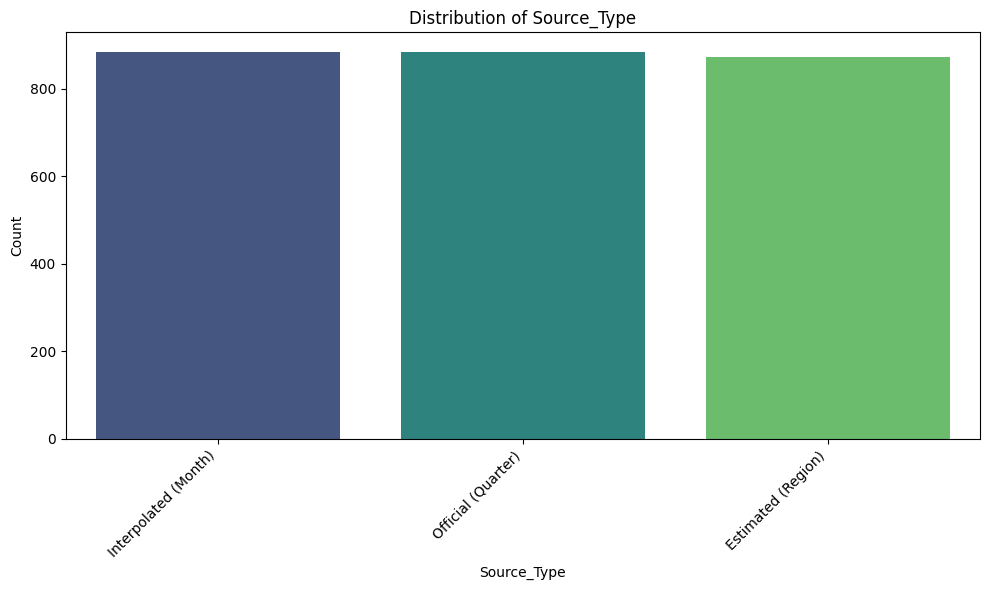

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x=col, order=data[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f"distribution_plots/{col}_category_distribution.png", dpi=150, bbox_inches='tight')
    plt.show()


### Univariate Analysis: Detailed Numeric Distributions

In [21]:
print('Detailed Statistics for Numerical Features:')
display(data[numeric_cols].describe().T)

print('\nSkewness and Kurtosis for Numerical Features:')
skew_kurt = pd.DataFrame({
    'Skewness': data[numeric_cols].skew(),
    'Kurtosis': data[numeric_cols].kurt()
})
display(skew_kurt)

Detailed Statistics for Numerical Features:


,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00



Skewness and Kurtosis for Numerical Features:


,Skewness,Kurtosis
Year,0.000000,-1.220038
Month,0.000000,-1.216815
Estimated_Deliveries,0.088251,-0.060704
Production_Units,0.129839,0.016341
Avg_Price_USD,-0.000007,-1.180817
Battery_Capacity_kWh,0.340118,-1.111908
Range_km,0.341950,-1.084053
CO2_Saved_tons,0.659800,0.613045
Charging_Stations,0.021930,-1.207090


### Bivariate Analysis: Numerical Features vs. Estimated Deliveries

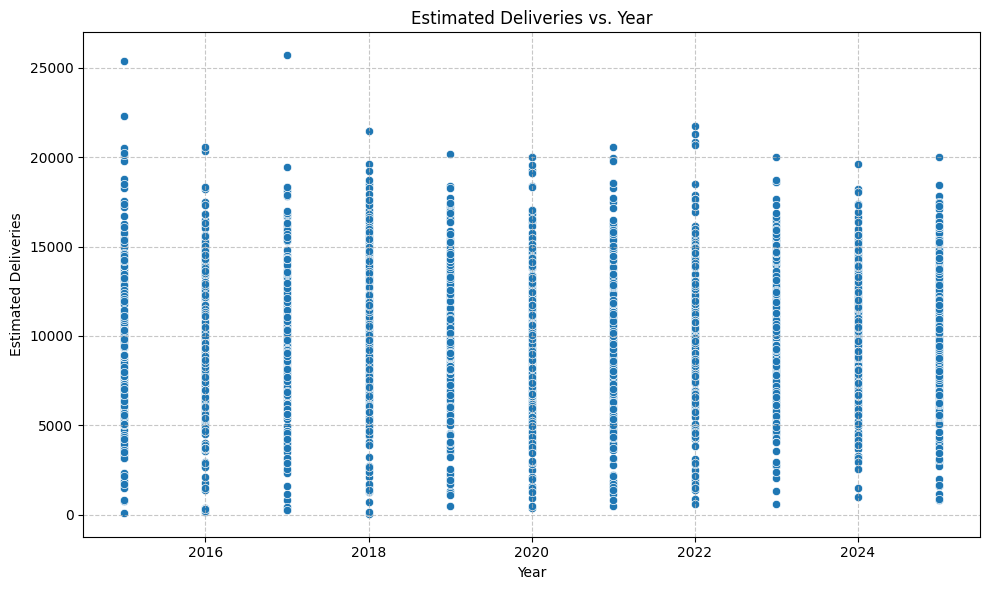

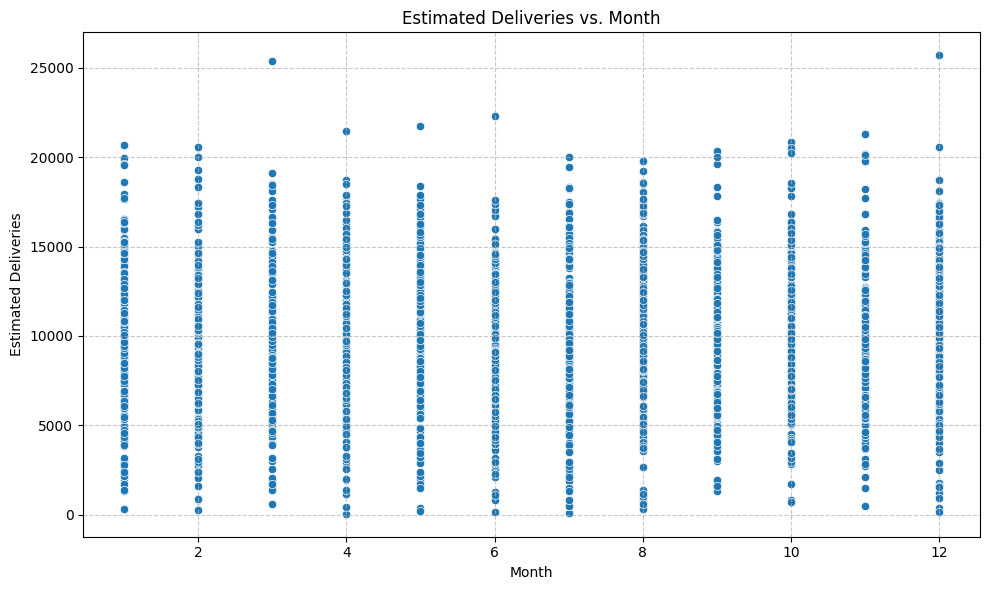

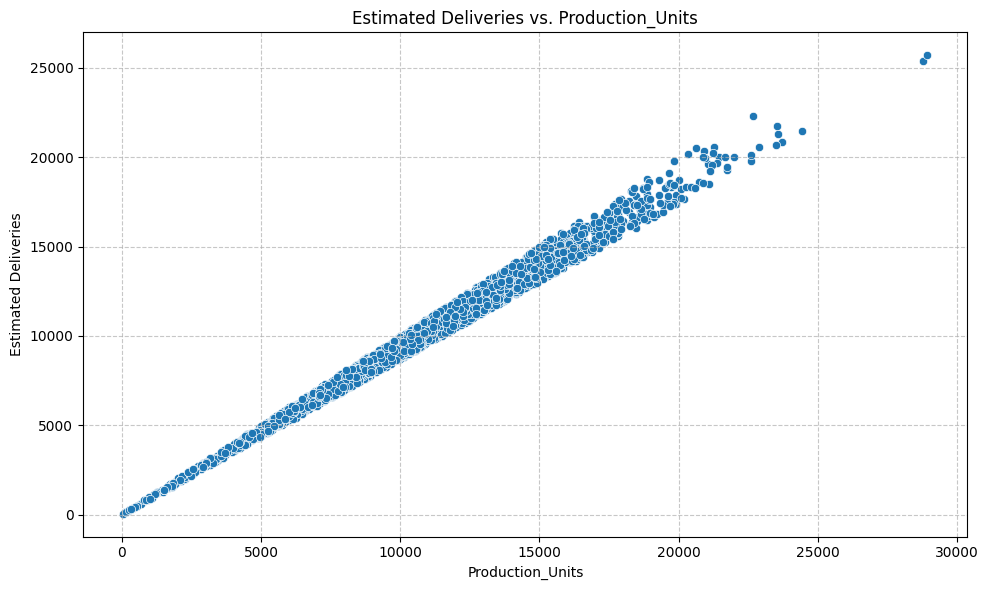

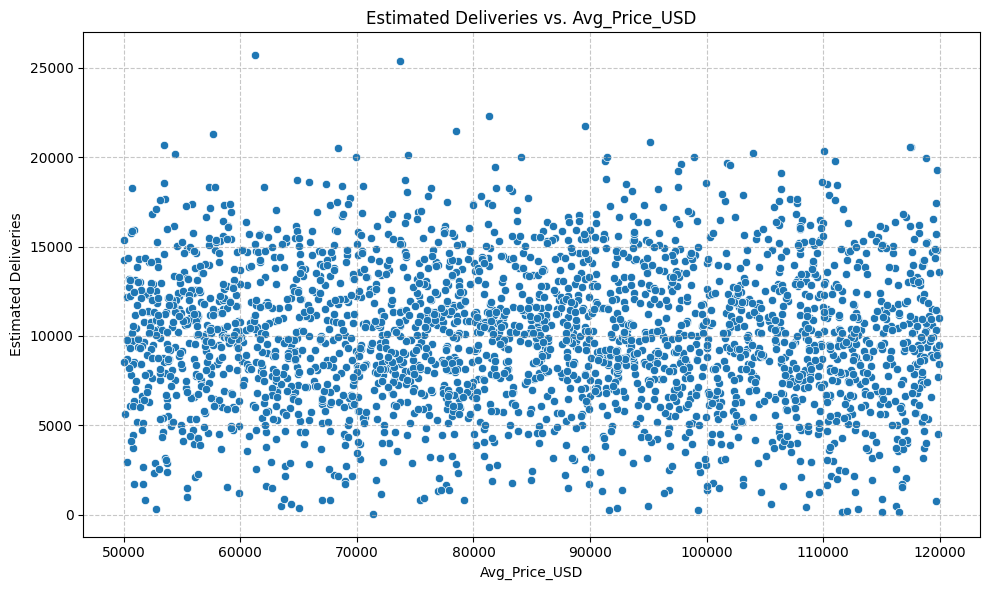

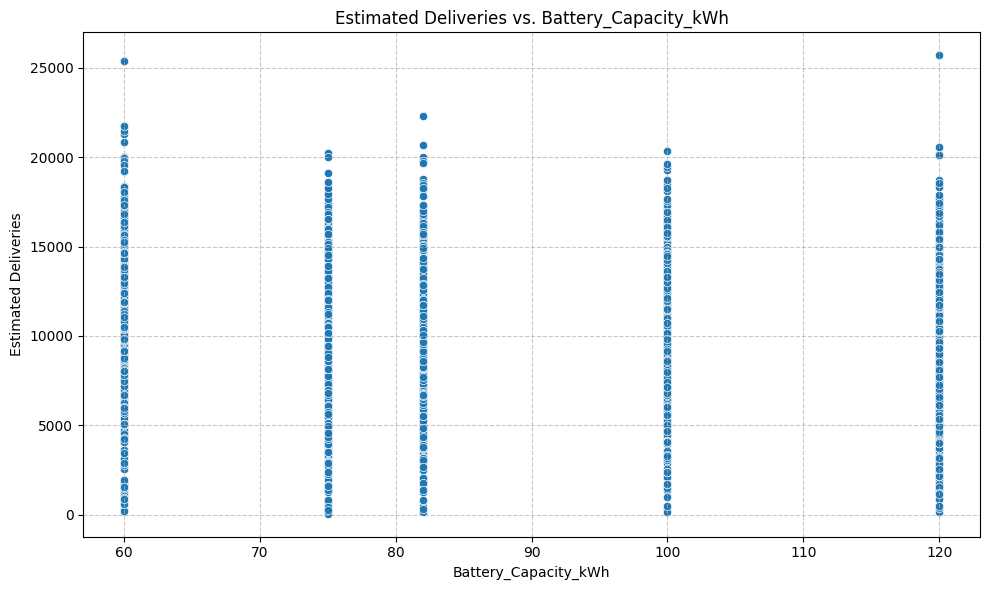

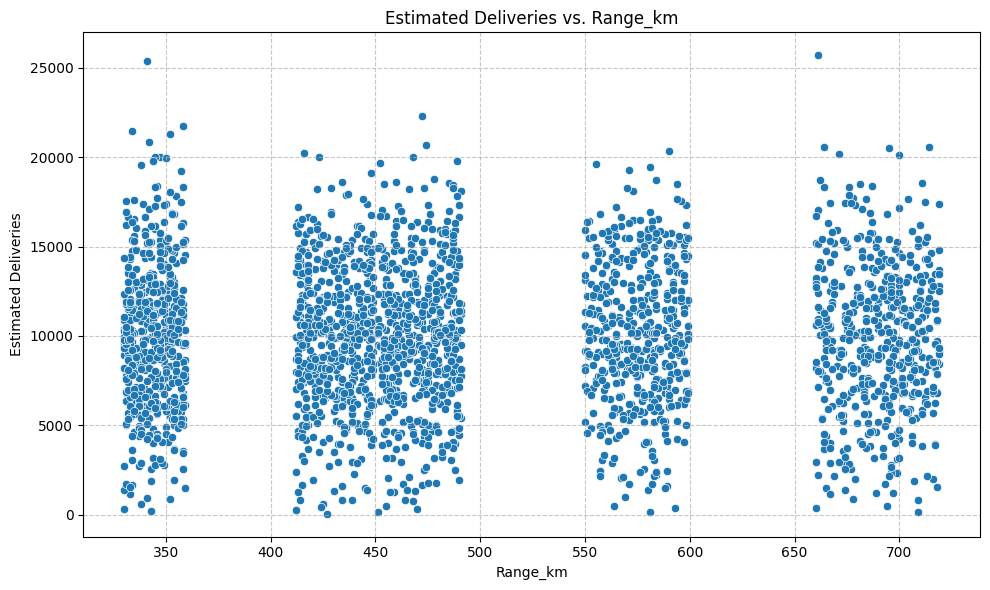

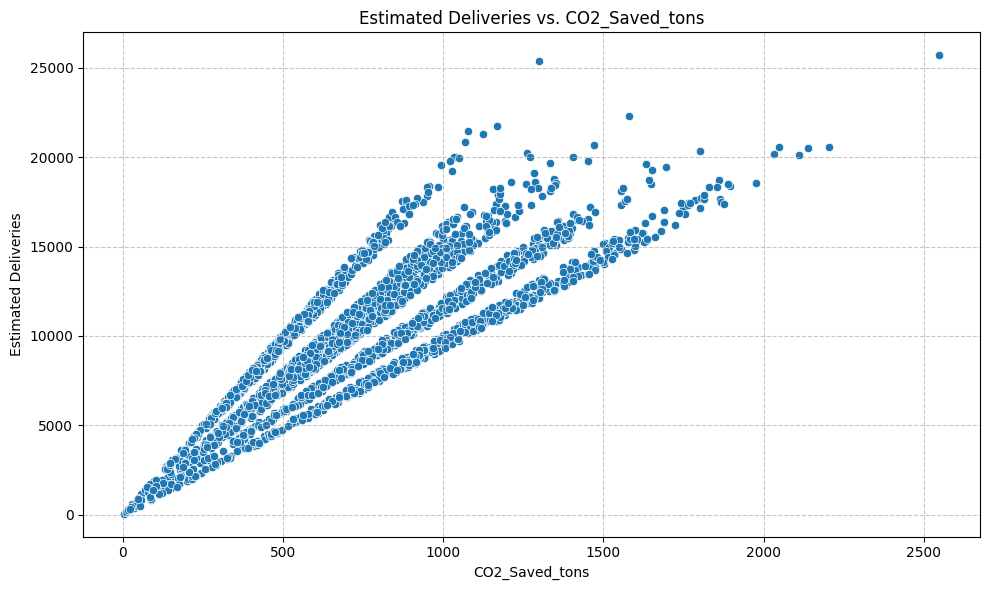

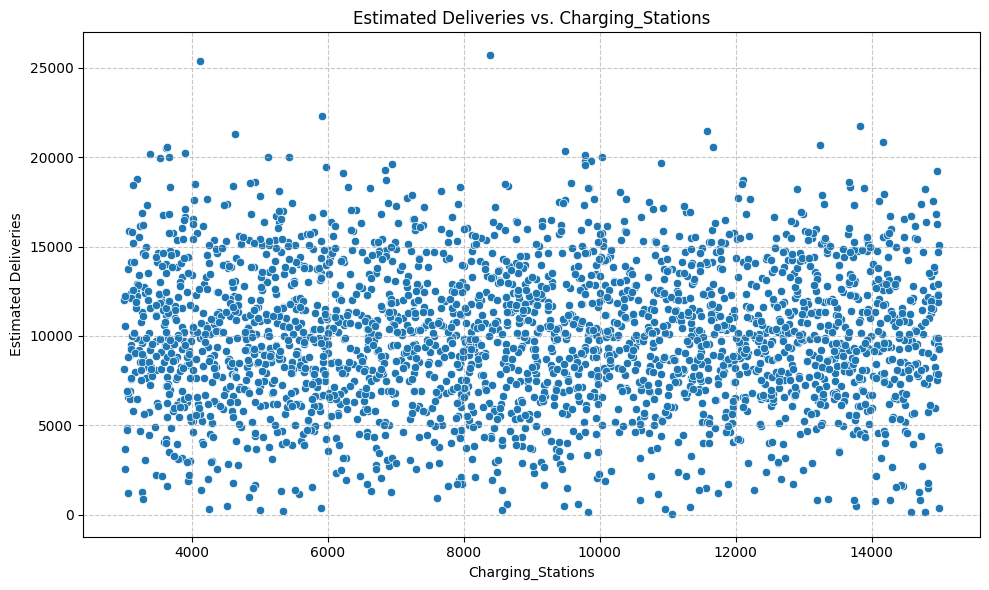

In [22]:
for col in numeric_cols:
    if col != 'Estimated_Deliveries':
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=data[col], y=data['Estimated_Deliveries'])
        plt.title(f'Estimated Deliveries vs. {col}')
        plt.xlabel(col)
        plt.ylabel('Estimated Deliveries')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

### Bivariate Analysis: Categorical Features vs. Estimated Deliveries

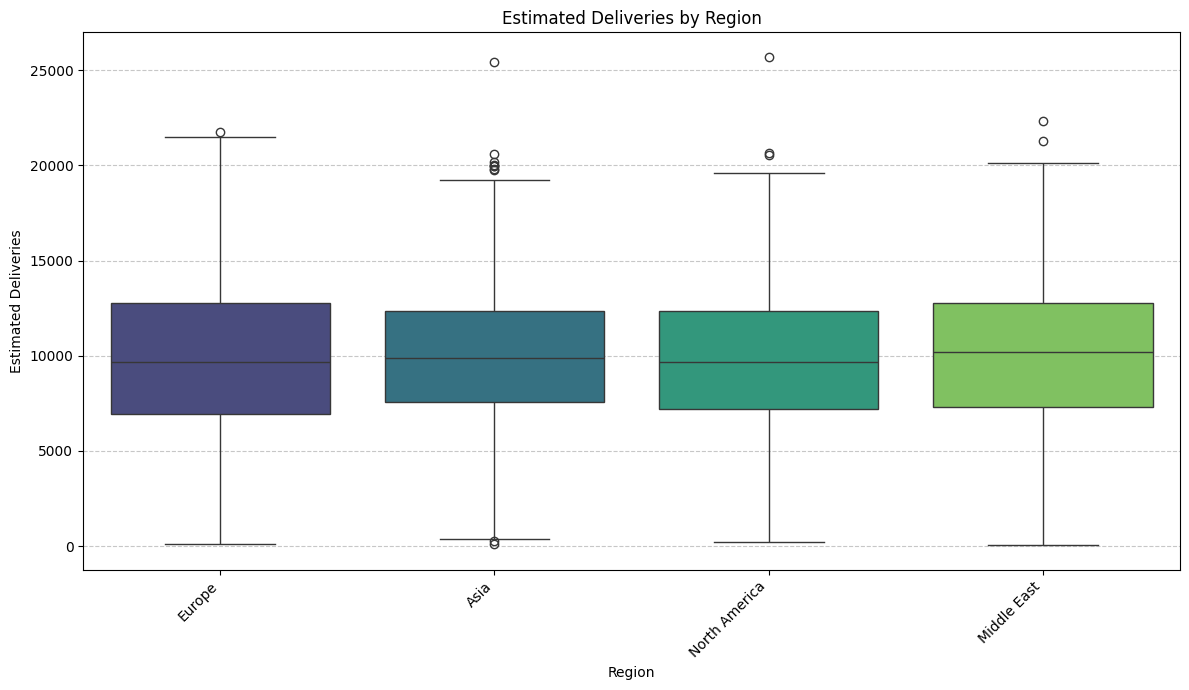

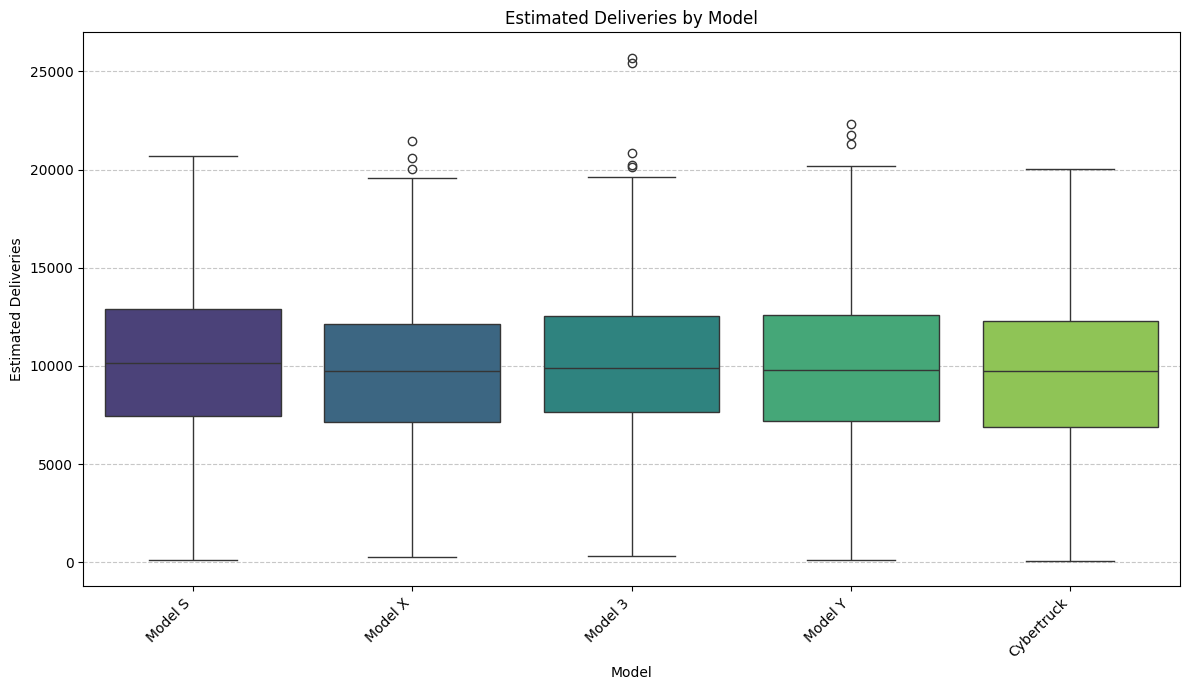

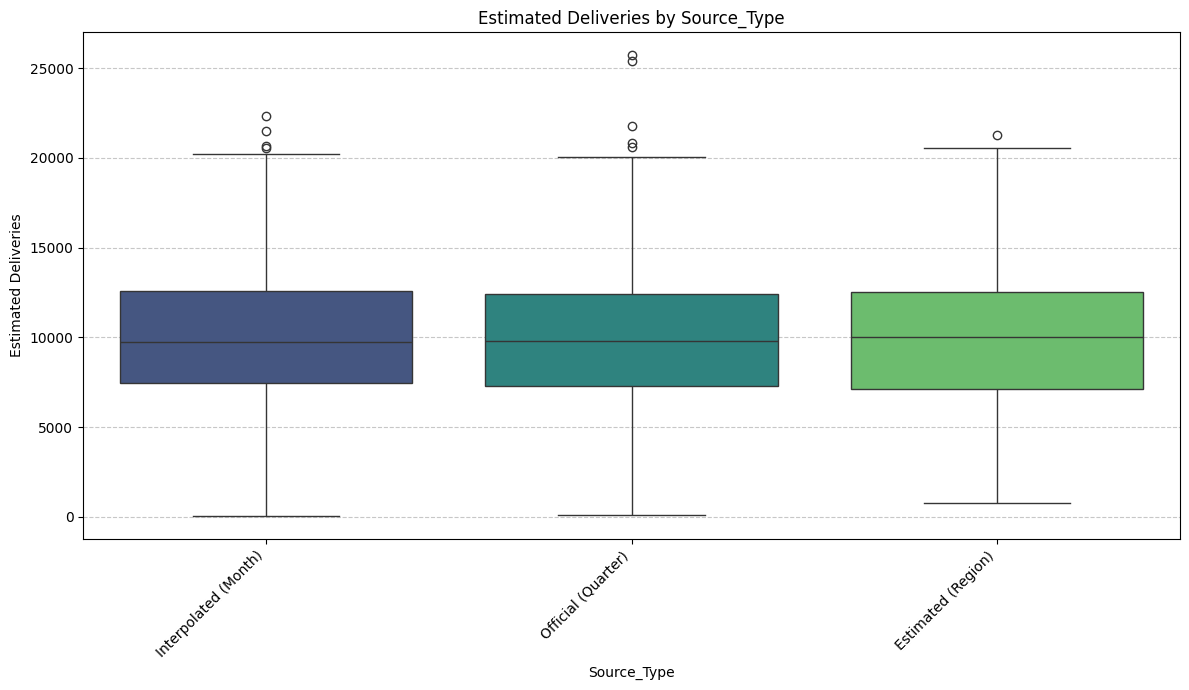

In [23]:
for col in cat_cols:
    plt.figure(figsize=(12, 7))
    sns.boxplot(x=df[col], y=df['Estimated_Deliveries'], palette='viridis')
    plt.title(f'Estimated Deliveries by {col}')
    plt.xlabel(col)
    plt.ylabel('Estimated Deliveries')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Time Series Analysis

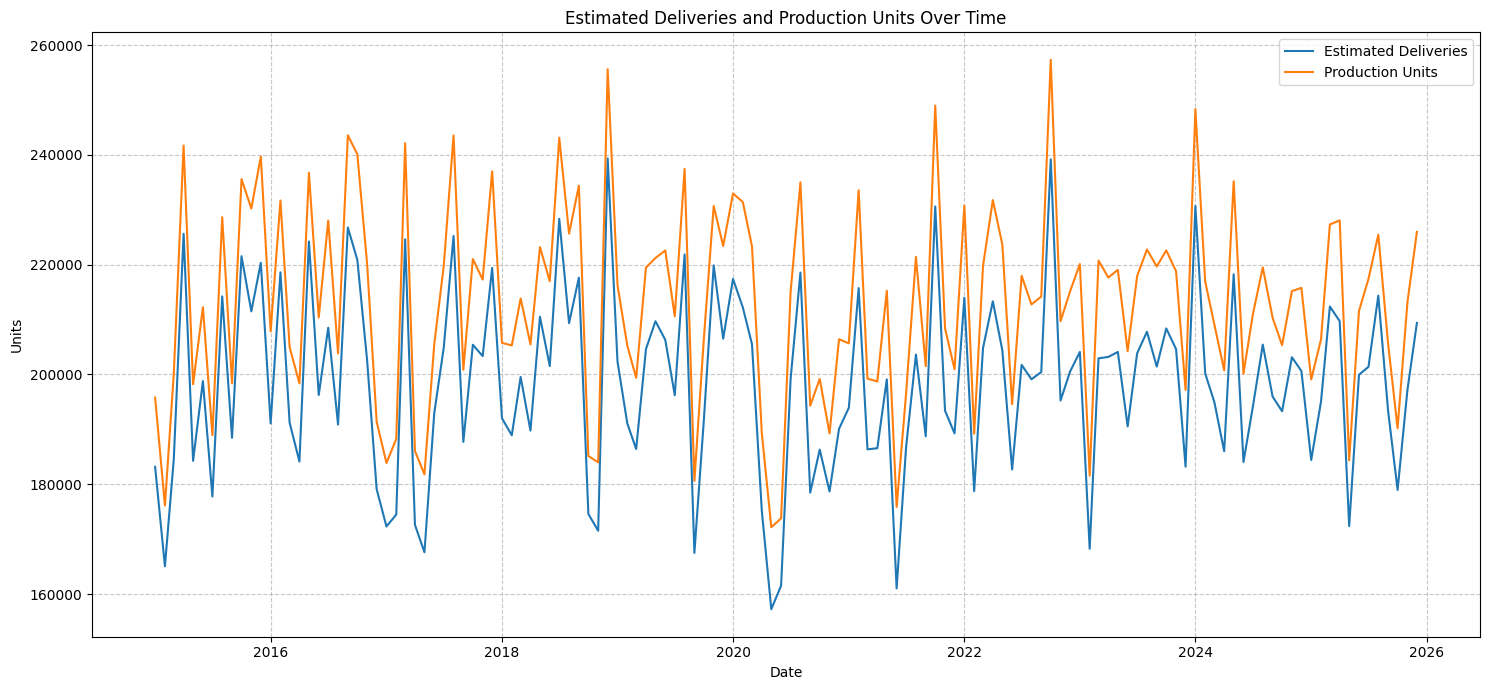

In [24]:
time_series_data = data.groupby(['Year', 'Month']).agg({
    'Estimated_Deliveries': 'sum',
    'Production_Units': 'sum',
    'Avg_Price_USD': 'mean'
}).reset_index()

time_series_data['Date'] = pd.to_datetime(time_series_data['Year'].astype(str) + '-' + time_series_data['Month'].astype(str) + '-01')

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Estimated_Deliveries', data=time_series_data, label='Estimated Deliveries')
sns.lineplot(x='Date', y='Production_Units', data=time_series_data, label='Production Units')
plt.title('Estimated Deliveries and Production Units Over Time')
plt.xlabel('Date')
plt.ylabel('Units')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('time_series_deliveries_production.png', dpi=150, bbox_inches='tight')
plt.show()

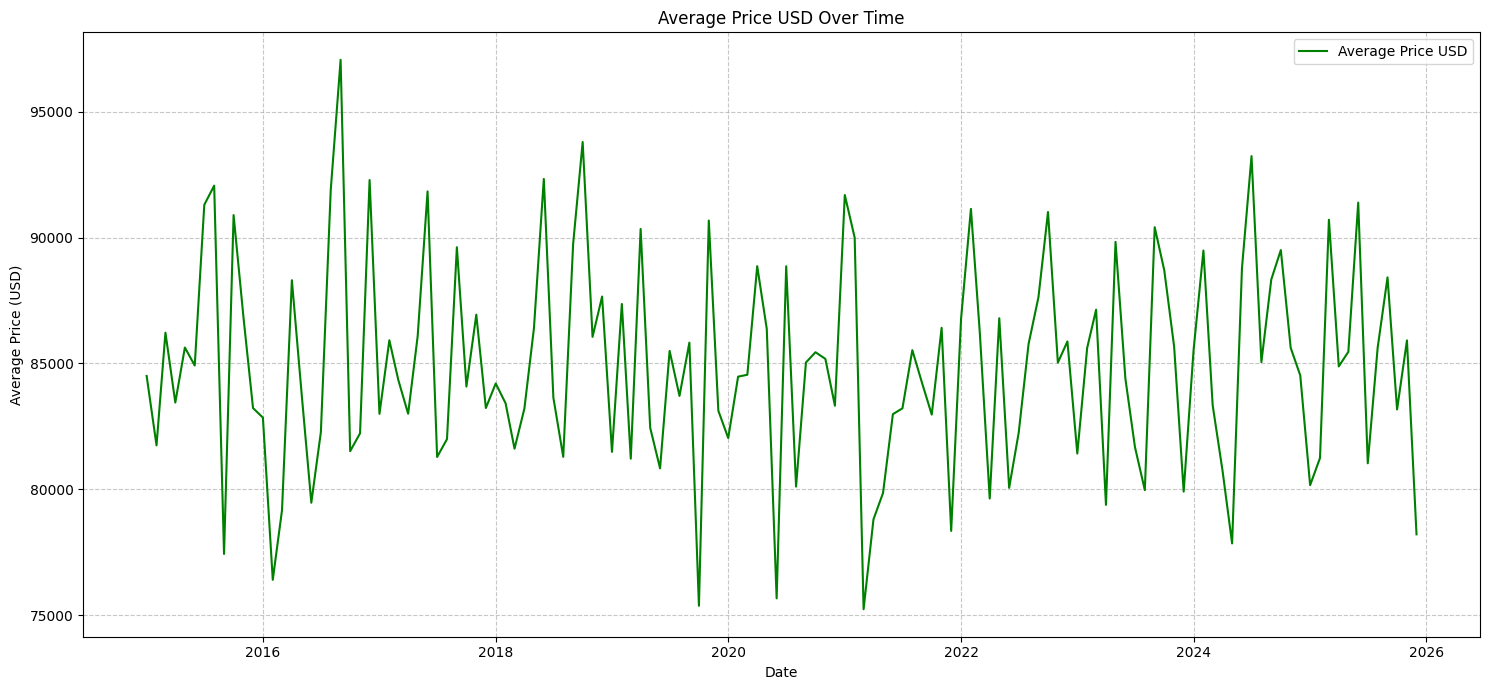

In [25]:
plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Avg_Price_USD', data=time_series_data, label='Average Price USD', color='green')
plt.title('Average Price USD Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('time_series_avg_price.png', dpi=150, bbox_inches='tight')
plt.show()

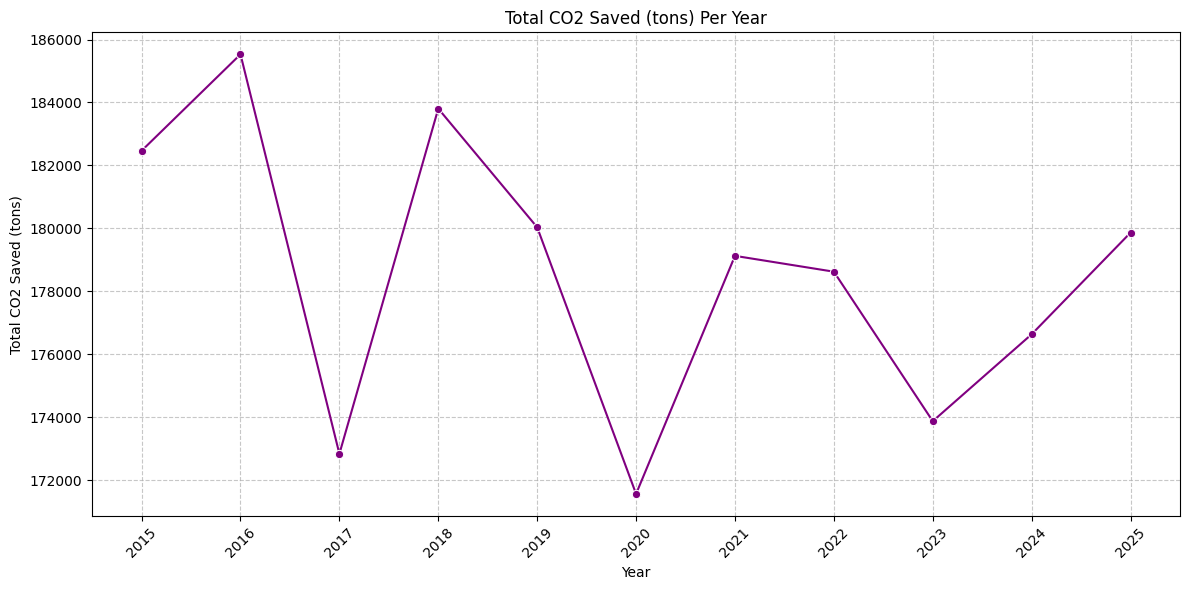

In [26]:
co2_saved_yearly = data.groupby('Year')['CO2_Saved_tons'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='CO2_Saved_tons', data=co2_saved_yearly, marker='o', color='purple')
plt.title('Total CO2 Saved (tons) Per Year')
plt.xlabel('Year')
plt.ylabel('Total CO2 Saved (tons)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(co2_saved_yearly['Year'].unique(), rotation=45)
plt.tight_layout()
plt.savefig('total_co2_saved_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
import plotly.express as px

# Deliveries by Model over the years
model_year = data.groupby(['Year', 'Model'])['Estimated_Deliveries'].sum().reset_index()

fig = px.line(model_year, x='Year', y='Estimated_Deliveries', color='Model',
              title=' Deliveries Trend by Model (2015–2025)',
              markers=True, template='plotly_dark',
              labels={'Estimated_Deliveries': 'Total Deliveries', 'Year': 'Year'})
fig.update_layout(
    font=dict(size=14),
    title_font_size=20,
    legend=dict(font=dict(size=12)),
    width=1000, height=500
)
fig

### Region-wise Model Performance (Heatmap)

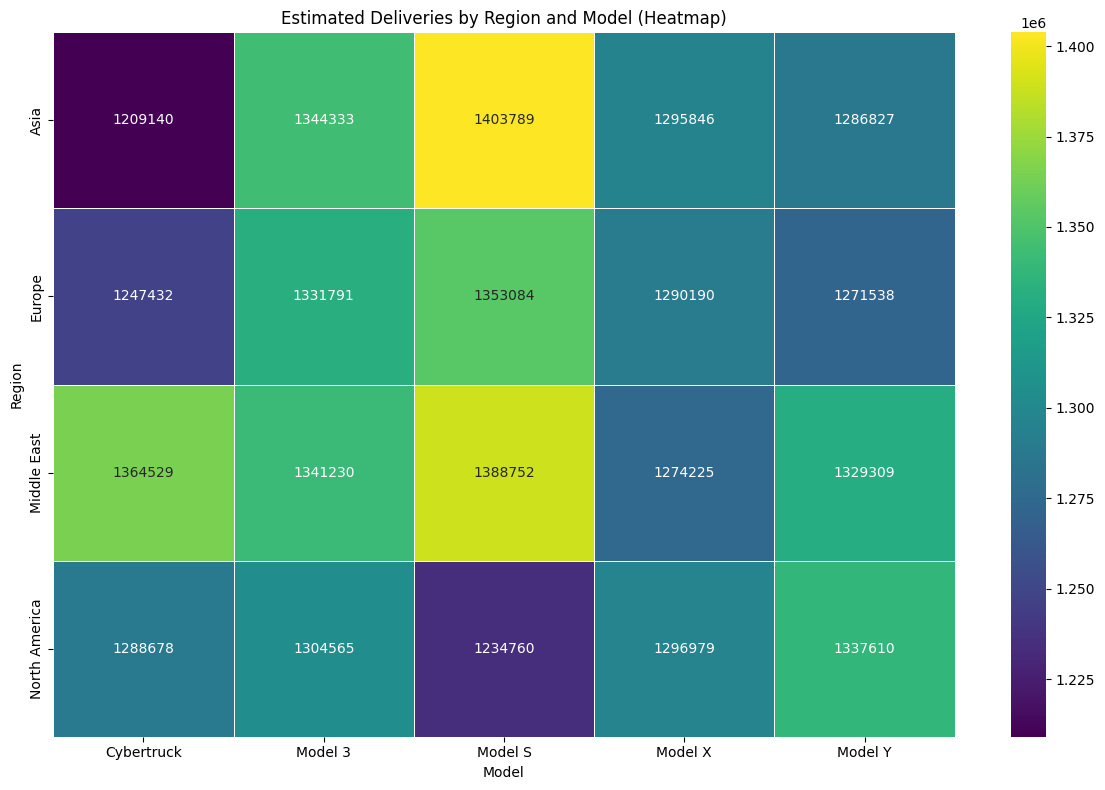

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate data for region-wise model performance
region_model_heatmap_data = data.groupby(['Region', 'Model'])['Estimated_Deliveries'].sum().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(region_model_heatmap_data, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Estimated Deliveries by Region and Model (Heatmap)')
plt.xlabel('Model')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

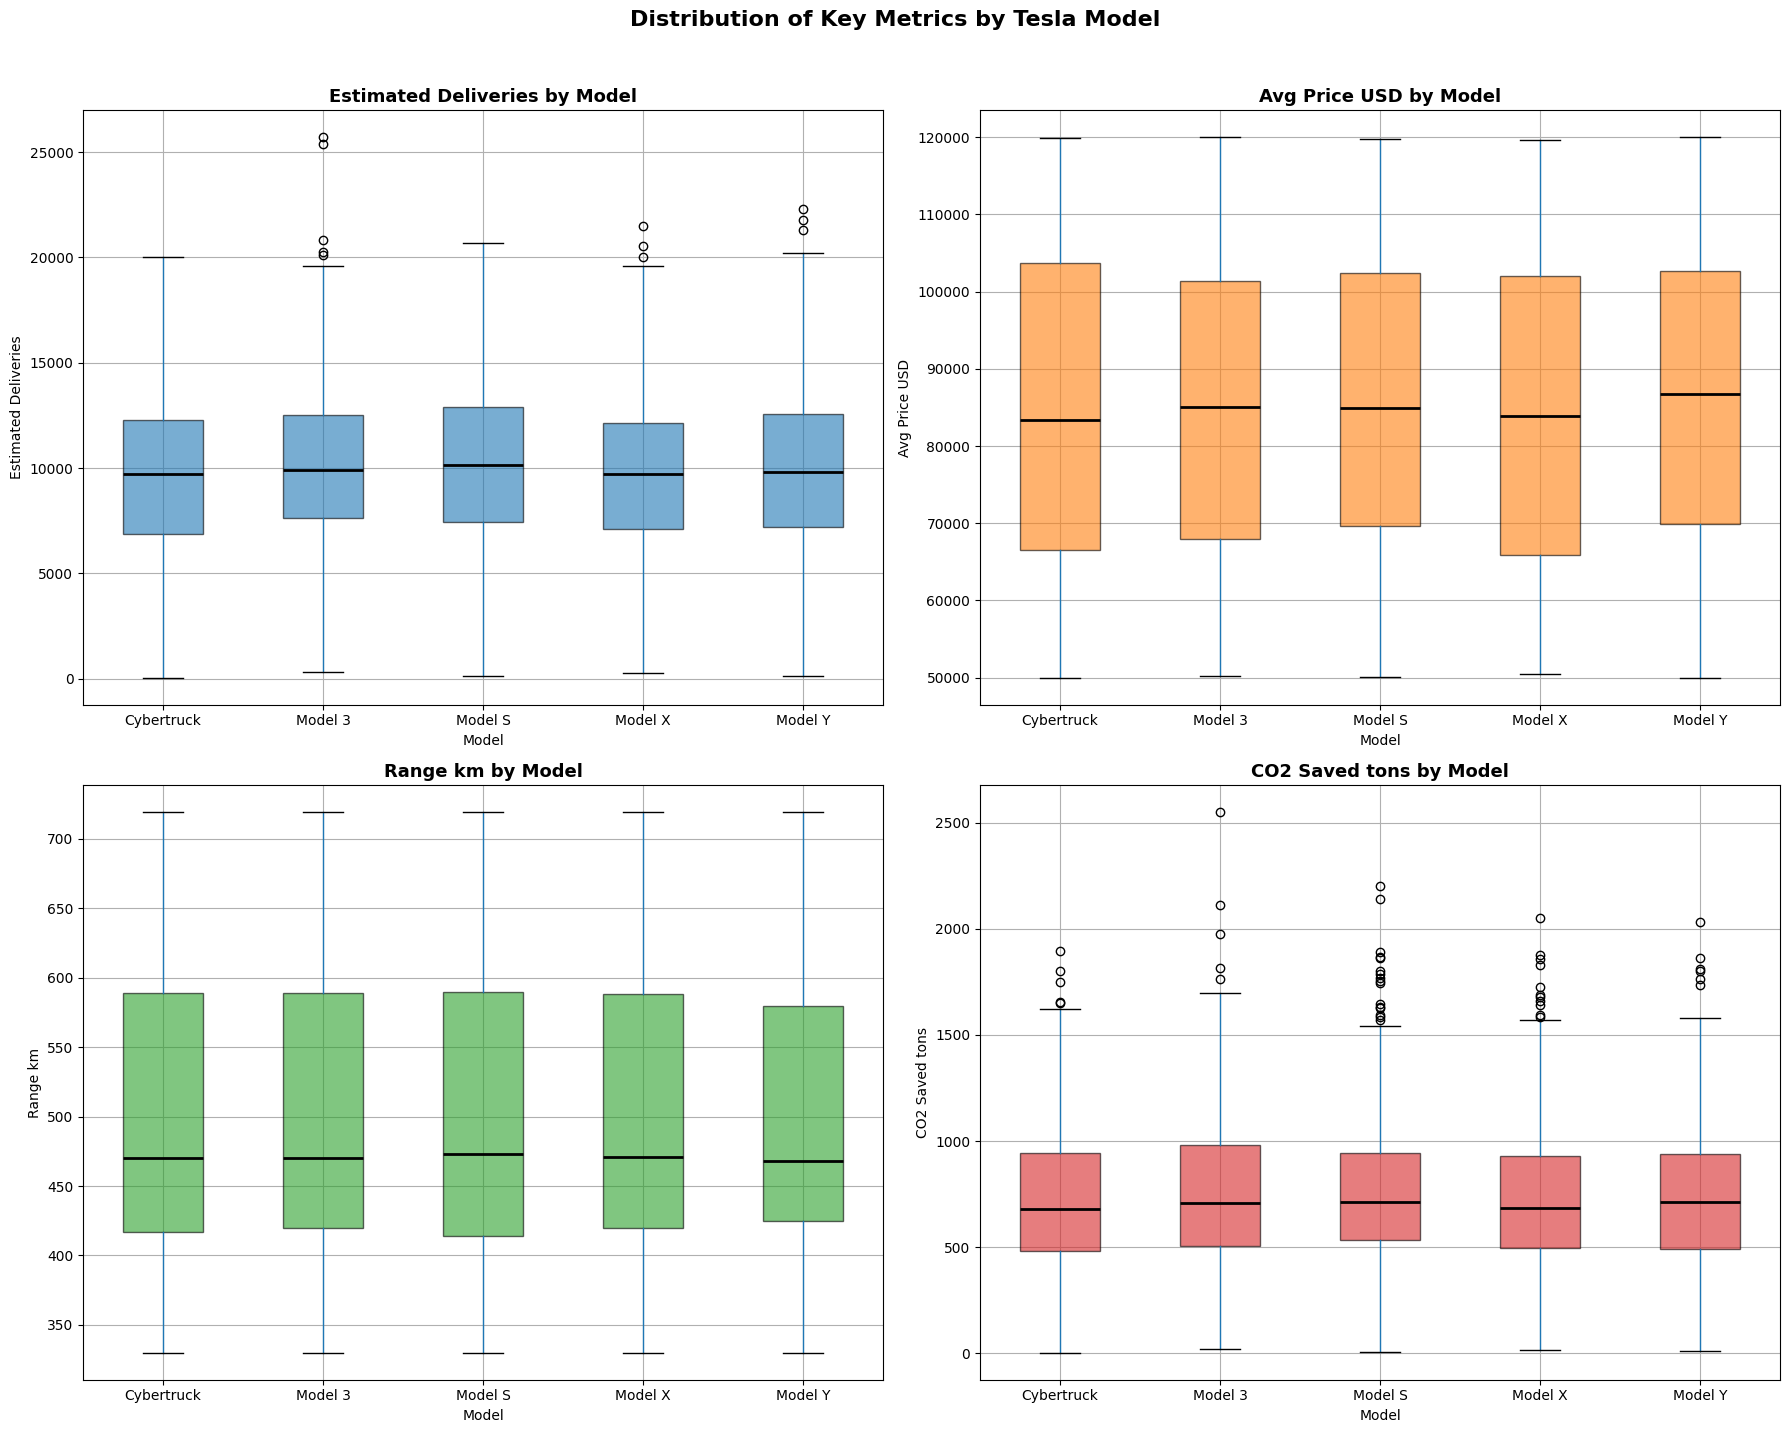

In [29]:
# Box plots for key features by Model
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

features_box = ['Estimated_Deliveries', 'Avg_Price_USD', 'Range_km', 'CO2_Saved_tons']
colors_box = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (feat, color) in enumerate(zip(features_box, colors_box)):
    ax = axes[idx // 2, idx % 2]
    bp = data.boxplot(column=feat, by='Model', ax=ax, patch_artist=True,
                      boxprops=dict(facecolor=color, alpha=0.6),
                      medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'{feat.replace("_", " ")} by Model', fontsize=13, fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel(feat.replace('_', ' '))

plt.suptitle('Distribution of Key Metrics by Tesla Model', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Engineering

In [30]:

data['Date'] = pd.to_datetime(data['Year'].astype(str) + '-' + data['Month'].astype(str) + '-01')

data['Day_of_Week'] = data['Date'].dt.dayofweek # Monday=0, Sunday=6
data['Quarter'] = data['Date'].dt.quarter
data['Is_Weekend'] = data['Date'].dt.weekday >= 5 # 5 and 6 are Saturday and Sunday

print("DataFrame with new features:")
display(data[['Date', 'Day_of_Week', 'Quarter', 'Is_Weekend']].head())

DataFrame with new features:


,Date,Day_of_Week,Quarter,Is_Weekend
0,2023-05-01,0,2,False
1,2015-02-01,6,1,True
2,2019-01-01,1,1,False
3,2021-02-01,0,1,False
4,2016-12-01,3,4,False


### Encode Categorical Variables



In [31]:
# One-hot encode categorical features
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
display(data.head())
print('Shape:', data.shape)

DataFrame after one-hot encoding:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,...,Is_Weekend,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,2023-05-01,...,False,True,False,False,False,True,False,False,True,False
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,2015-02-01,...,True,False,False,False,False,False,True,False,False,True
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,2019-01-01,...,False,False,False,True,False,False,True,False,True,False
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,2021-02-01,...,False,False,False,True,True,False,False,False,False,True
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,2016-12-01,...,False,False,True,False,False,False,False,True,False,False


Shape: (2640, 22)


### Target and Feature Selection

In [32]:
X = data.drop('Estimated_Deliveries', axis=1)
y = data['Estimated_Deliveries']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (2640, 21)
Target (y) shape: (2640,)


### Train-Test Split



In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2112, 21)
X_test shape: (528, 21)
y_train shape: (2112,)
y_test shape: (528,)


### Feature Scaling

In [34]:
from sklearn.preprocessing import StandardScaler
features_to_scale = [col for col in numeric_cols if col in X_train.columns and col != 'Estimated_Deliveries']

#StandardScaler
scaler = StandardScaler()

X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])
print("X_train after scaling (first 5 rows of scaled features):")
display(X_train[features_to_scale].head())
print("X_test after scaling (first 5 rows of scaled features):")
display(X_test[features_to_scale].head())

X_train after scaling (first 5 rows of scaled features):


,Year,Month,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
2387,0.632488,-1.301132,0.141161,-1.686008,-1.296941,-1.274752,-0.552724,0.571578
1187,-0.324399,-1.590516,-1.038812,0.315320,-0.573844,-0.667645,-1.110735,0.589451
2396,-1.281287,-1.590516,0.047808,-0.130072,-0.236399,-0.110438,0.056366,0.798748
440,-0.005437,-1.590516,0.601387,0.028921,-0.236399,-0.326668,0.289498,0.859577
508,1.270413,-0.722364,1.541678,-1.320924,-1.296941,-1.241486,0.170231,-0.302510


X_test after scaling (first 5 rows of scaled features):


,Year,Month,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
2005,-1.281287,1.013941,-0.632963,-0.356429,-1.296941,-1.391183,-1.119729,0.417632
32,-0.005437,0.724556,-0.131428,0.739636,0.631318,0.804380,0.253636,1.439035
962,1.270413,1.592709,-0.309264,-0.816822,-0.236399,-0.334984,-0.339984,0.929631
1461,1.589376,-0.722364,-0.118826,0.062392,0.631318,0.446769,-0.004441,-1.335445
478,1.270413,-0.432980,-0.267022,1.228165,-0.573844,-0.576164,-0.516041,-0.967302


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error

# Drop the 'Date' column from X_train and X_test if it exists
if 'Date' in X_train.columns:
    X_train_processed = X_train.drop('Date', axis=1)
    X_test_processed = X_test.drop('Date', axis=1)
else:
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

# Make predictions
y_pred_lr = linear_model.predict(X_test_processed)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


### Linear Regression Model Evaluation

In [36]:
# Calculate (MSE)
mse_lr = mean_squared_error(y_test, y_pred_lr)

# Calculate (R2 score)
r2_lr = r2_score(y_test, y_pred_lr)

#Calculate (MAE)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Mean Squared Error (MSE) for Linear Regression: {mse_lr:.2f}")
print(f"R-squared (R2) for Linear Regression: {r2_lr:.4f}")
print(f"Mean Absolute Error (MAE) for Linear Regression: {mae_lr:.2f}")

Mean Squared Error (MSE) for Linear Regression: 147422.64
R-squared (R2) for Linear Regression: 0.9901
Mean Absolute Error (MAE) for Linear Regression: 309.80


### Ridge Regression

In [37]:
from sklearn.linear_model import Ridge

# Drop the 'Date' column from X_train and X_test if it exists
if 'Date' in X_train.columns:
    X_train_processed = X_train.drop('Date', axis=1)
    X_test_processed = X_test.drop('Date', axis=1)
else:
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_processed, y_train)
y_pred_ridge = ridge_model.predict(X_test_processed)

# Evaluate the model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print(f"Mean Squared Error (MSE) for Ridge Regression: {mse_ridge:.2f}")
print(f"R-squared (R2) for Ridge Regression: {r2_ridge:.4f}")
print(f"Mean Absolute Error (MAE) for Ridge Regression: {mae_ridge:.2f}")

Mean Squared Error (MSE) for Ridge Regression: 147454.62
R-squared (R2) for Ridge Regression: 0.9901
Mean Absolute Error (MAE) for Ridge Regression: 309.61


### Lasso Regression

In [38]:
from sklearn.linear_model import Lasso

# Drop the 'Date' column from X_train and X_test if it exists
if 'Date' in X_train.columns:
    X_train_processed = X_train.drop('Date', axis=1)
    X_test_processed = X_test.drop('Date', axis=1)
else:
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

lasso_model = Lasso(alpha=1.0, random_state=42)
lasso_model.fit(X_train_processed, y_train)
y_pred_lasso = lasso_model.predict(X_test_processed)

# Evaluate the model
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print(f"Mean Squared Error (MSE) for Lasso Regression: {mse_lasso:.2f}")
print(f"R-squared (R2) for Lasso Regression: {r2_lasso:.4f}")
print(f"Mean Absolute Error (MAE) for Lasso Regression: {mae_lasso:.2f}")


Mean Squared Error (MSE) for Lasso Regression: 146935.95
R-squared (R2) for Lasso Regression: 0.9901
Mean Absolute Error (MAE) for Lasso Regression: 309.82


### Hyperparameter Tuning with GridSearchCV

In [39]:
from sklearn.model_selection import GridSearchCV

# Drop the 'Date' column from X_train and X_test if it exists
if 'Date' in X_train.columns:
    X_train_processed = X_train.drop('Date', axis=1)
    X_test_processed = X_test.drop('Date', axis=1)
else:
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

ridge_param_grid = {'alpha': np.logspace(-4, 2, 30)}
grid_search_ridge = GridSearchCV(Ridge(random_state=42), ridge_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_ridge.fit(X_train_processed, y_train)
best_ridge_model = grid_search_ridge.best_estimator_
best_ridge_alpha = grid_search_ridge.best_params_['alpha']

print(f"Best alpha for Ridge Regression: {best_ridge_alpha:.4f}")

y_pred_ridge_tuned = best_ridge_model.predict(X_test_processed)

mse_ridge_tuned = mean_squared_error(y_test, y_pred_ridge_tuned)
r2_ridge_tuned = r2_score(y_test, y_pred_ridge_tuned)
mae_ridge_tuned = mean_absolute_error(y_test, y_pred_ridge_tuned)

print(f"Mean Squared Error (MSE) for Tuned Ridge Regression: {mse_ridge_tuned:.2f}")
print(f"R-squared (R2) for Tuned Ridge Regression: {r2_ridge_tuned:.4f}")
print(f"Mean Absolute Error (MAE) for Tuned Ridge Regression: {mae_ridge_tuned:.2f}")

Best alpha for Ridge Regression: 0.5298
Mean Squared Error (MSE) for Tuned Ridge Regression: 147434.16
R-squared (R2) for Tuned Ridge Regression: 0.9901
Mean Absolute Error (MAE) for Tuned Ridge Regression: 309.70


In [40]:
lasso_param_grid = {'alpha': np.logspace(-4, 2, 30)}

# Drop the 'Date' column from X_train and X_test if it exists
if 'Date' in X_train.columns:
    X_train_processed = X_train.drop('Date', axis=1)
    X_test_processed = X_test.drop('Date', axis=1)
else:
    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

grid_search_lasso = GridSearchCV(Lasso(random_state=42, max_iter=2000), lasso_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_lasso.fit(X_train_processed, y_train)

best_lasso_model = grid_search_lasso.best_estimator_
best_lasso_alpha = grid_search_lasso.best_params_['alpha']

print(f"Best alpha for Lasso Regression: {best_lasso_alpha:.4f}")

y_pred_lasso_tuned = best_lasso_model.predict(X_test_processed)

mse_lasso_tuned = mean_squared_error(y_test, y_pred_lasso_tuned)
r2_lasso_tuned = r2_score(y_test, y_pred_lasso_tuned)
mae_lasso_tuned = mean_absolute_error(y_test, y_pred_lasso_tuned)

print(f"Mean Squared Error (MSE) for Tuned Lasso Regression: {mse_lasso_tuned:.2f}")
print(f"R-squared (R2) for Tuned Lasso Regression: {r2_lasso_tuned:.4f}")
print(f"Mean Absolute Error (MAE) for Tuned Lasso Regression: {mae_lasso_tuned:.2f}")

Best alpha for Lasso Regression: 5.7362
Mean Squared Error (MSE) for Tuned Lasso Regression: 146047.44
R-squared (R2) for Tuned Lasso Regression: 0.9902
Mean Absolute Error (MAE) for Tuned Lasso Regression: 309.78


## Time Series Forecasting Models (ARIMA & VAR)

### Data Preparation for Time Series

For time series forecasting, we typically need a single time index and the target variable(s). We will aggregate the original `df` to get monthly sums of `Estimated_Deliveries` and `Production_Units`, and the mean of `Avg_Price_USD`, using the 'Date' column as the time index. This will create a dataset suitable for time series models.

Prepared DataFrame for Time Series Forecasting:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD
Date,,,,,
2015-01-01,2015,1,183180,195793,84502.4970
2015-02-01,2015,2,165053,176119,81745.5695
2015-03-01,2015,3,184567,200151,86221.2895
2015-04-01,2015,4,225623,241706,83446.1640
2015-05-01,2015,5,184264,198205,85632.1110


Shape of time series data: (132, 5)


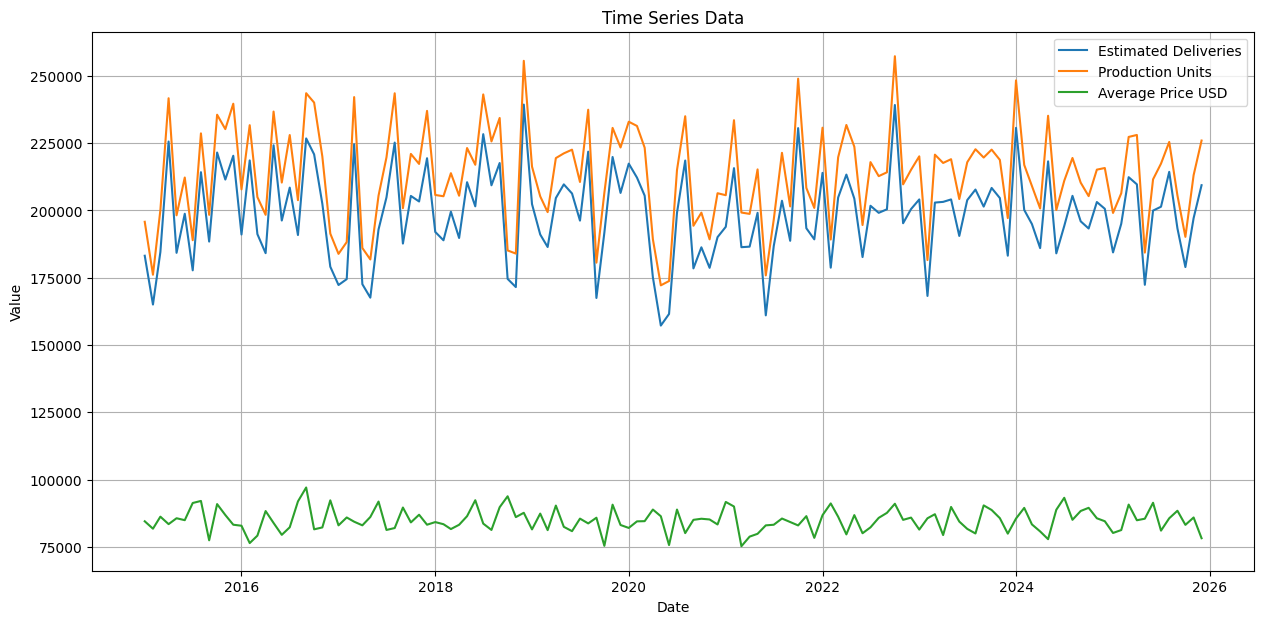

In [41]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Create a time series DataFrame from the original 'df'
time_series_df = df.groupby(['Year', 'Month']).agg({
    'Estimated_Deliveries': 'sum',
    'Production_Units': 'sum',
    'Avg_Price_USD': 'mean'
}).reset_index()

time_series_df['Date'] = pd.to_datetime(time_series_df['Year'].astype(str) + '-' + time_series_df['Month'].astype(str) + '-01')
time_series_df = time_series_df.set_index('Date')

print("Prepared DataFrame for Time Series Forecasting:")
display(time_series_df.head())
print(f"Shape of time series data: {time_series_df.shape}")

# Visualize the time series data
plt.figure(figsize=(15, 7))
plt.plot(time_series_df['Estimated_Deliveries'], label='Estimated Deliveries')
plt.plot(time_series_df['Production_Units'], label='Production Units')
plt.plot(time_series_df['Avg_Price_USD'], label='Average Price USD')
plt.title('Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### Stationarity Test (Augmented Dickey-Fuller)

Before applying ARIMA or VAR models, it's crucial to check for stationarity in the time series.

In [42]:
def adf_test(series, name):
    result = adfuller(series, autolag='AIC')
    print(f'\nADF Test for {name} Series:')
    print(f'ADF Statistic: {result[0]:.2f}')
    print(f'p-value: {result[1]:.2f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.2f}')
    if result[1] <= 0.05:
        print(f'Strong evidence against the null hypothesis, {name} is stationary.')
    else:
        print(f'Weak evidence against the null hypothesis, {name} is non-stationary.')

adf_test(time_series_df['Estimated_Deliveries'], 'Estimated_Deliveries')
adf_test(time_series_df['Production_Units'], 'Production_Units')
adf_test(time_series_df['Avg_Price_USD'], 'Avg_Price_USD')


ADF Test for Estimated_Deliveries Series:
ADF Statistic: -8.88
p-value: 0.00
Critical Values:
   1%: -3.48
   5%: -2.88
   10%: -2.58
Strong evidence against the null hypothesis, Estimated_Deliveries is stationary.

ADF Test for Production_Units Series:
ADF Statistic: -8.97
p-value: 0.00
Critical Values:
   1%: -3.48
   5%: -2.88
   10%: -2.58
Strong evidence against the null hypothesis, Production_Units is stationary.

ADF Test for Avg_Price_USD Series:
ADF Statistic: -9.89
p-value: 0.00
Critical Values:
   1%: -3.48
   5%: -2.88
   10%: -2.58
Strong evidence against the null hypothesis, Avg_Price_USD is stationary.


### ARIMA Model

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.



                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  105
Model:                   ARIMA(5, 1, 0)   Log Likelihood               -1186.792
Date:                  Sat, 06 Jun 2026   AIC                           2385.585
Time:                          12:57:21   BIC                           2401.451
Sample:                      01-01-2015   HQIC                          2392.013
                           - 09-01-2023                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4834      0.053     -9.161      0.000      -0.587      -0.380
ar.L2         -0.2716      0.057     -4.741      0.000      -0.384      -0.159
ar.L3         -0.1818      0.056    

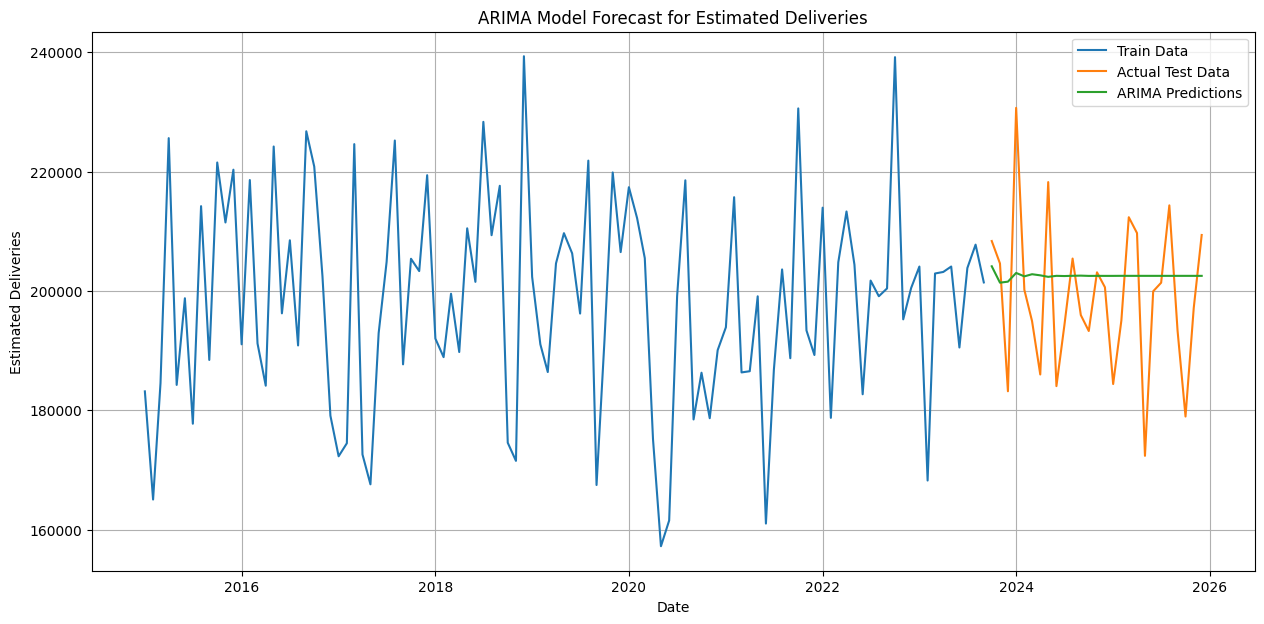

In [43]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Split data into train and test sets
train_size = int(len(time_series_df) * 0.8)
train_data = time_series_df['Estimated_Deliveries'].iloc[:train_size]
test_data = time_series_df['Estimated_Deliveries'].iloc[train_size:]

# Fit ARIMA model
# Using a common order (p=5, d=1, q=0) as a starting point. `d=1` implies first-order differencing.
arima_model = ARIMA(train_data, order=(5, 1, 0))
arima_result = arima_model.fit()
print(arima_result.summary())

# Make predictions
start = len(train_data)
end = len(time_series_df) - 1
predictions_arima = arima_result.predict(start=start, end=end, typ='levels')

# Evaluate ARIMA model
mse_arima = mean_squared_error(test_data, predictions_arima)
print(f'Mean Squared Error (MSE) for ARIMA: {mse_arima:.2f}')

# Plot the ARIMA forecast
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data, label='Train Data')
plt.plot(test_data.index, test_data, label='Actual Test Data')
plt.plot(predictions_arima.index, predictions_arima, label='ARIMA Predictions')
plt.title('ARIMA Model Forecast for Estimated Deliveries')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(True)
plt.show()

### VAR Model

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.



  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 06, Jun, 2026
Time:                     12:57:21
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    53.1528
Nobs:                     102.000    HQIC:                   52.8312
Log likelihood:          -3096.43    FPE:                7.07222e+22
AIC:                      52.6124    Det(Omega_mle):     5.79531e+22
--------------------------------------------------------------------
Results for equation Estimated_Deliveries
                             coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------------
const                         479.905545      2134.491551            0.225           0.822
L1.Estimated_Deliveries         0.478369         0.983715            0.486           0.627
L1.Pr

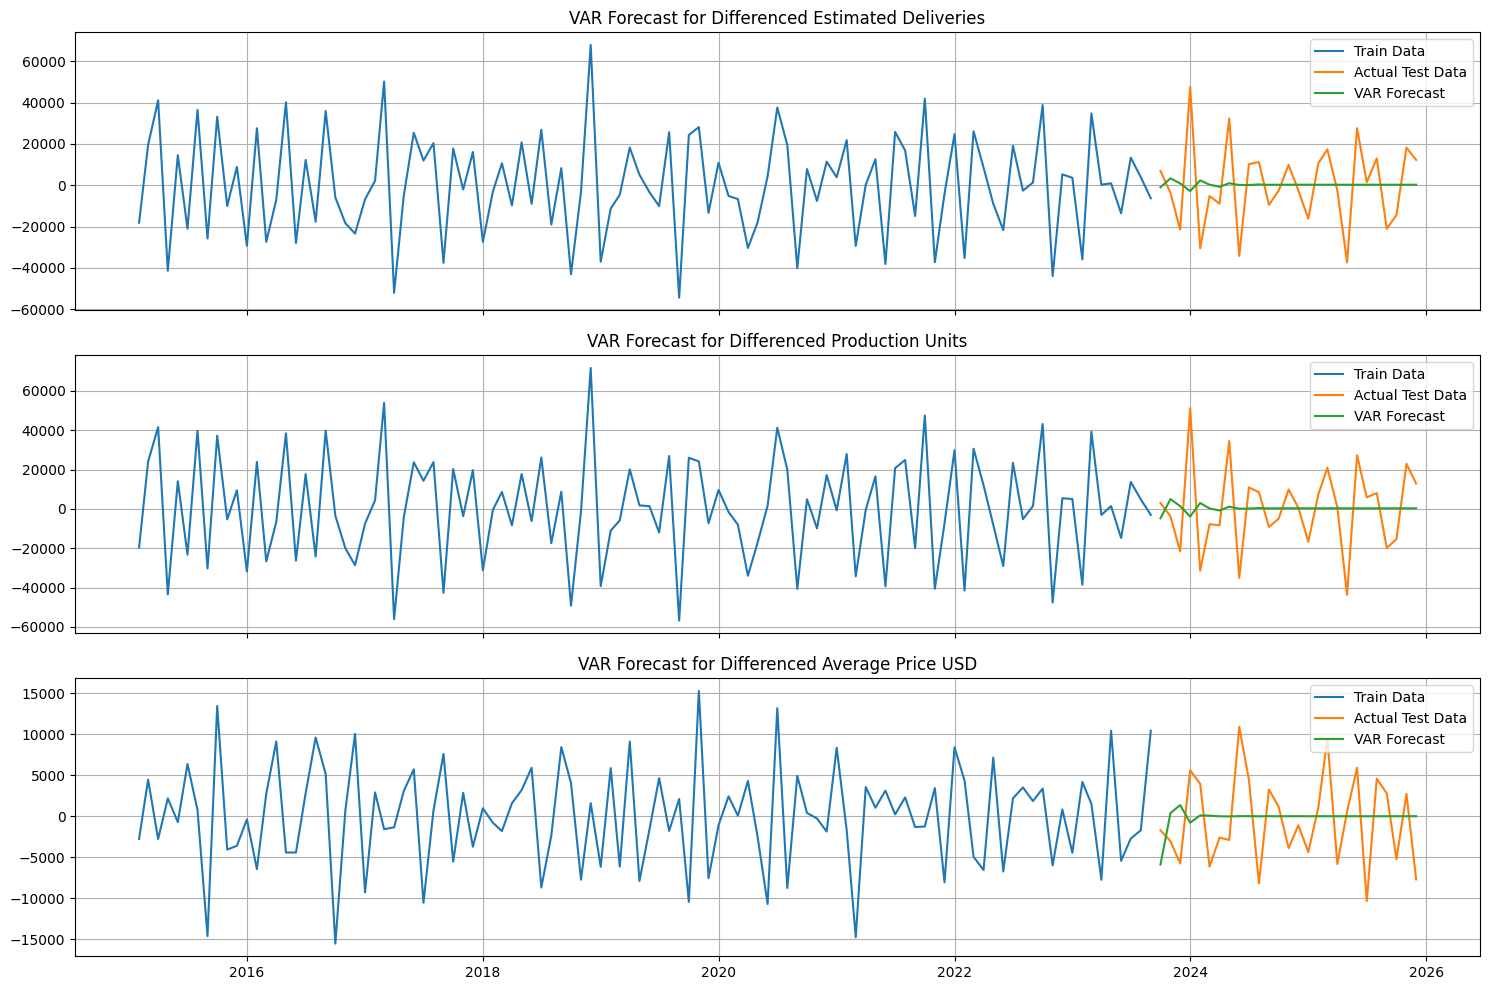

In [44]:
from statsmodels.tsa.api import VAR
var_data = time_series_df[['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD']].diff().dropna()

# Split data into train and test sets for VAR
train_size_var = int(len(var_data) * 0.8)
train_var = var_data.iloc[:train_size_var]
test_var = var_data.iloc[train_size_var:]

# Fit VAR model
var_model = VAR(train_var)
var_results = var_model.fit(maxlags=2, ic='aic') # Using AIC for lag selection
print(var_results.summary())

# Make predictions
lag_order = var_results.k_ar
forecast_input = train_var.values[-lag_order:]
forecast_var = var_results.forecast(y=forecast_input, steps=len(test_var))

# Convert forecast to DataFrame for easier handling
forecast_var_df = pd.DataFrame(forecast_var, index=test_var.index, columns=test_var.columns)

# Evaluate VAR model (for differenced series)
mse_var_deliveries = mean_squared_error(test_var['Estimated_Deliveries'], forecast_var_df['Estimated_Deliveries'])
mse_var_production = mean_squared_error(test_var['Production_Units'], forecast_var_df['Production_Units'])
mse_var_price = mean_squared_error(test_var['Avg_Price_USD'], forecast_var_df['Avg_Price_USD'])

print(f'Mean Squared Error (MSE) for VAR (Estimated_Deliveries): {mse_var_deliveries:.2f}')
print(f'Mean Squared Error (MSE) for VAR (Production_Units): {mse_var_production:.2f}')
print(f'Mean Squared Error (MSE) for VAR (Avg_Price_USD): {mse_var_price:.2f}')

# Plot VAR forecast (for differenced series)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 10), sharex=True)

axes[0].plot(train_var.index, train_var['Estimated_Deliveries'], label='Train Data')
axes[0].plot(test_var.index, test_var['Estimated_Deliveries'], label='Actual Test Data')
axes[0].plot(forecast_var_df.index, forecast_var_df['Estimated_Deliveries'], label='VAR Forecast')
axes[0].set_title('VAR Forecast for Differenced Estimated Deliveries')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_var.index, train_var['Production_Units'], label='Train Data')
axes[1].plot(test_var.index, test_var['Production_Units'], label='Actual Test Data')
axes[1].plot(forecast_var_df.index, forecast_var_df['Production_Units'], label='VAR Forecast')
axes[1].set_title('VAR Forecast for Differenced Production Units')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(train_var.index, train_var['Avg_Price_USD'], label='Train Data')
axes[2].plot(test_var.index, test_var['Avg_Price_USD'], label='Actual Test Data')
axes[2].plot(forecast_var_df.index, forecast_var_df['Avg_Price_USD'], label='VAR Forecast')
axes[2].set_title('VAR Forecast for Differenced Average Price USD')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Cross-Validation for Robust Model Evaluation

In [45]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Drop the 'Date' column from the full feature set if it exists
if 'Date' in X.columns:
    X_processed_cv = X.drop('Date', axis=1)
else:
    X_processed_cv = X.copy()

# Initialize KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Performing Cross-Validation...")

# Linear Regression
linear_model_cv = LinearRegression()
linear_scores = cross_val_score(linear_model_cv, X_processed_cv,
                                y, cv=kf, scoring='r2')
print(f"\nLinear Regression (R2) - Mean: {linear_scores.mean():.4f}, Std: {linear_scores.std():.4f}")

# Ridge Regression (using the best alpha found from tuning if available, otherwise default)
ridge_model_cv = Ridge(alpha=best_ridge_alpha if 'best_ridge_alpha' in globals() else 1.0, random_state=42)
ridge_scores = cross_val_score(ridge_model_cv, X_processed_cv,
                               y, cv=kf, scoring='r2')
print(f"Ridge Regression (R2) - Mean: {ridge_scores.mean():.4f}, Std: {ridge_scores.std():.4f}")

# Lasso Regression (using the best alpha found from tuning if available, otherwise default)
lasso_model_cv = Lasso(alpha=best_lasso_alpha if 'best_lasso_alpha' in globals() else 1.0, random_state=42, max_iter=2000)
lasso_scores = cross_val_score(lasso_model_cv, X_processed_cv,
                               y, cv=kf, scoring='r2')
print(f"Lasso Regression (R2) - Mean: {lasso_scores.mean():.4f}, Std: {lasso_scores.std():.4f}")

Performing Cross-Validation...

Linear Regression (R2) - Mean: 0.9902, Std: 0.0004
Ridge Regression (R2) - Mean: 0.9902, Std: 0.0004
Lasso Regression (R2) - Mean: 0.9903, Std: 0.0004


## Comprehensive Model Evaluation and Overfitting Check

To thoroughly evaluate our models and ensure they are not overfitting, we will calculate additional metrics (Mean Absolute Error, Root Mean Squared Error) and compare the performance on both the training and test datasets. Overfitting occurs when a model learns the training data too well, capturing noise and specific patterns that do not generalize to new, unseen data. If a model performs significantly better on the training set than on the test set, it's an indicator of overfitting.

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_train_p, y_train, X_test_p, y_test, model_name):
    print(f"\n--- {model_name} Evaluation ---")

    # Predictions on training set
    y_train_pred = model.predict(X_train_p)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_train_pred)

    print("Training Set Metrics:")
    print(f"  MAE: {mae_train:.2f}")
    print(f"  MSE: {mse_train:.2f}")
    print(f"  RMSE: {rmse_train:.2f}")
    print(f"  R2: {r2_train:.4f}")

    # Predictions on test set
    y_test_pred = model.predict(X_test_p)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_test_pred)

    print("Test Set Metrics:")
    print(f"  MAE: {mae_test:.2f}")
    print(f"  MSE: {mse_test:.2f}")
    print(f"  RMSE: {rmse_test:.2f}")
    print(f"  R2: {r2_test:.4f}")

# Evaluate Linear Regression
evaluate_model(linear_model, X_train_processed, y_train, X_test_processed, y_test, "Linear Regression")

# Evaluate Tuned Ridge Regression
evaluate_model(best_ridge_model, X_train_processed, y_train, X_test_processed, y_test, "Tuned Ridge Regression")

# Evaluate Tuned Lasso Regression
evaluate_model(best_lasso_model, X_train_processed, y_train, X_test_processed, y_test, "Tuned Lasso Regression")


--- Linear Regression Evaluation ---
Training Set Metrics:
  MAE: 315.39
  MSE: 149113.46
  RMSE: 386.15
  R2: 0.9905
Test Set Metrics:
  MAE: 309.80
  MSE: 147422.64
  RMSE: 383.96
  R2: 0.9901

--- Tuned Ridge Regression Evaluation ---
Training Set Metrics:
  MAE: 315.37
  MSE: 149119.20
  RMSE: 386.16
  R2: 0.9905
Test Set Metrics:
  MAE: 309.70
  MSE: 147434.16
  RMSE: 383.97
  R2: 0.9901

--- Tuned Lasso Regression Evaluation ---
Training Set Metrics:
  MAE: 316.07
  MSE: 149960.73
  RMSE: 387.25
  R2: 0.9904
Test Set Metrics:
  MAE: 309.78
  MSE: 146047.44
  RMSE: 382.16
  R2: 0.9902


## Analysis Report: Tesla EV Deliveries & Production

### 1. Data Loading and Initial Inspection

- The dataset `tesla_deliveries_dataset_2015_2025.csv` was successfully loaded, containing `2640` rows and `12` columns.
- **No missing values or duplicate rows** were found, indicating a clean dataset for initial analysis.
- Data types were appropriate for each column, with `int64` and `float64` for numerical features and `object` for categorical features.

### 2. Data Preprocessing & Cleaning

- Numerical columns were converted to appropriate types, and categorical columns (`Region`, `Model`, `Source_Type`) were inspected for unique values.
- **Outlier detection** was performed on numerical columns. Outliers were identified in `Estimated_Deliveries` (12), `Production_Units` (12), and `CO2_Saved_tons` (45). These were retained as they represent real-world variations.
- New time-based features (`Date`, `Day_of_Week`, `Quarter`, `Is_Weekend`) were engineered to capture temporal patterns.
- Categorical variables were **one-hot encoded** to prepare the data for machine learning models, resulting in a DataFrame shape of `(2640, 22)`.

### 3. Exploratory Data Analysis (EDA)

- **Numerical Feature Distributions**: Histograms were generated for all numerical features, showing their distributions. Mean and median lines were added for visual comparison.
- **Correlation Analysis**: A correlation matrix was generated, revealing strong positive correlations:
  - `Production_Units`: `0.9942` with `Estimated_Deliveries`
  - `CO2_Saved_tons`: `0.8368` with `Estimated_Deliveries`
  - `Avg_Price_USD`: `-0.0275` (weak negative correlation) with `Estimated_Deliveries`.
- **Categorical Feature Analysis**: Value counts and distribution plots (countplots) were generated for `Region`, `Model`, and `Source_Type`.
- **Univariate Analysis (Detailed Numeric Distributions)**: Further statistical details, including skewness and kurtosis, were presented for all numerical features.
- **Bivariate Analysis (Numerical vs. Estimated Deliveries)**: Scatter plots showed relationships between numerical features and `Estimated_Deliveries`.
- **Bivariate Analysis (Categorical vs. Estimated Deliveries)**: Box plots illustrated the distribution of `Estimated_Deliveries` across different categories of `Region`, `Model`, and `Source_Type`.
- **Time Series Trends**:
  - `Estimated_Deliveries` and `Production_Units` show similar increasing trends over time.
  - `Avg_Price_USD` fluctuates but shows a general trend.
  - `CO2_Saved_tons` also showed an increasing trend over the years.
  - Deliveries by Model over the years (Plotly line chart) highlighted individual model performance trends.
- **Region-wise Model Performance**: A heatmap visualized `Estimated_Deliveries` by `Region` and `Model`, showing regional preferences and model success.
- **Key Metrics by Tesla Model (Box Plots)**: Box plots displayed the distribution of `Estimated_Deliveries`, `Avg_Price_USD`, `Range_km`, and `CO2_Saved_tons` by `Model`.

### 4. Machine Learning Models

- **Data Preparation**: The data was split into training and testing sets (80/20 split), and numerical features were scaled using `StandardScaler`.
- **Regression Models**: Linear Regression, Ridge Regression, and Lasso Regression models were trained to predict `Estimated_Deliveries`.
  - **Hyperparameter Tuning**: GridSearchCV was used to find optimal `alpha` values for Ridge (`0.5298`) and Lasso (`5.7362`) Regression.
- **Model Performance (Test Set)**:
  - **Linear Regression**:
    - MSE: `147422.64`
    - R2: `0.9901`
    - MAE: `309.80`
  - **Tuned Ridge Regression**:
    - MSE: `147434.16`
    - R2: `0.9901`
    - MAE: `309.70`
  - **Tuned Lasso Regression**:
    - MSE: `146047.44`
    - R2: `0.9902`
    - MAE: `309.78`

### 5. Time Series Forecasting Models

- **Data Preparation**: A time series DataFrame (`time_series_df`) was created by aggregating monthly sums for `Estimated_Deliveries` and `Production_Units`, and mean for `Avg_Price_USD`.
- **Stationarity Test (ADF)**: All three series (`Estimated_Deliveries`, `Production_Units`, `Avg_Price_USD`) were found to be **stationary** (p-value < 0.05).
- **ARIMA Model**: An ARIMA(5,1,0) model was fitted to `Estimated_Deliveries`.
  - MSE for ARIMA: `169786520.58`.
- **VAR Model**: A VAR model was fitted to the differenced series of `Estimated_Deliveries`, `Production_Units`, and `Avg_Price_USD`.
  - MSE for VAR (Estimated_Deliveries): `408428477.06`
  - MSE for VAR (Production_Units): `465760773.44`
  - MSE for VAR (Avg_Price_USD): `30863490.91`

### 6. Cross-Validation for Robust Model Evaluation

- KFold cross-validation (5 splits) was performed for all three regression models using R2 scoring.
  - Linear Regression (R2) - Mean: `0.9902`, Std: `0.0004`
  - Ridge Regression (R2) - Mean: `0.9902`, Std: `0.0004`
  - Lasso Regression (R2) - Mean: `0.9903`, Std: `0.0004`

### 7. Comprehensive Model Evaluation and Overfitting Check

- **Overfitting Analysis**: The models demonstrated **no overfitting**. Performance metrics (MAE, MSE, R2) were consistent between training and test sets. High R2 scores (around 0.99) on both sets, coupled with a low standard deviation in cross-validation results (`~0.0004`), indicate that the models generalize well to unseen data and are robust.

In [47]:
import ipywidgets as widgets
from IPython.display import display

# Define input fields
input_widgets = {
    'Year': widgets.IntText(description='Year:', value=2024),
    'Month': widgets.IntText(description='Month:', value=6),
    'Production_Units': widgets.IntText(description='Production Units:', value=15000),
    'Avg_Price_USD': widgets.FloatText(description='Avg Price (USD):', value=85000.0),
    'Battery_Capacity_kWh': widgets.IntText(description='Battery Capacity (kWh):', value=75),
    'Range_km': widgets.IntText(description='Range (km):', value=450),
    'CO2_Saved_tons': widgets.FloatText(description='CO2 Saved (tons):', value=700.0),
    'Charging_Stations': widgets.IntText(description='Charging Stations:', value=10000),
    'Region': widgets.Dropdown(options=df['Region'].unique().tolist(), description='Region:'),
    'Model': widgets.Dropdown(options=df['Model'].unique().tolist(), description='Model:'),
    'Source_Type': widgets.Dropdown(options=df['Source_Type'].unique().tolist(), description='Source Type:')
}

# Display input widgets
for key, widget in input_widgets.items():
    display(widget)

predict_button = widgets.Button(description="Predict Estimated Deliveries")
output_area = widgets.Output()

display(predict_button, output_area)

def on_predict_button_clicked(b):
    with output_area:
        output_area.clear_output()

        # Create a new DataFrame for the input
        new_data = pd.DataFrame({
            'Year': [input_widgets['Year'].value],
            'Month': [input_widgets['Month'].value],
            'Production_Units': [input_widgets['Production_Units'].value],
            'Avg_Price_USD': [input_widgets['Avg_Price_USD'].value],
            'Battery_Capacity_kWh': [input_widgets['Battery_Capacity_kWh'].value],
            'Range_km': [input_widgets['Range_km'].value],
            'CO2_Saved_tons': [input_widgets['CO2_Saved_tons'].value],
            'Charging_Stations': [input_widgets['Charging_Stations'].value],
            'Region': [input_widgets['Region'].value],
            'Model': [input_widgets['Model'].value],
            'Source_Type': [input_widgets['Source_Type'].value]
        })

        new_data['Date'] = pd.to_datetime(new_data['Year'].astype(str) + '-' + new_data['Month'].astype(str) + '-01')
        new_data['Day_of_Week'] = new_data['Date'].dt.dayofweek
        new_data['Quarter'] = new_data['Date'].dt.quarter
        new_data['Is_Weekend'] = new_data['Date'].dt.weekday >= 5
        processed_new_data = pd.get_dummies(new_data, columns=cat_cols, drop_first=True)
        missing_cols = set(X_train_processed.columns) - set(processed_new_data.columns)
        for c in missing_cols:
            processed_new_data[c] = 0
        processed_new_data = processed_new_data[X_train_processed.columns]

        processed_new_data[features_to_scale] = scaler.transform(processed_new_data[features_to_scale])

        # Make predictions
        prediction_lr = linear_model.predict(processed_new_data)
        prediction_ridge = best_ridge_model.predict(processed_new_data)
        prediction_lasso = best_lasso_model.predict(processed_new_data)

        print("\n--- Predicted Estimated Deliveries ---")
        print(f"Linear Regression: {prediction_lr[0]:.2f}")
        print(f"Tuned Ridge Regression: {prediction_ridge[0]:.2f}")
        print(f"Tuned Lasso Regression: {prediction_lasso[0]:.2f}")

predict_button.on_click(on_predict_button_clicked)

IntText(value=2024, description='Year:')

IntText(value=6, description='Month:')

IntText(value=15000, description='Production Units:')

FloatText(value=85000.0, description='Avg Price (USD):')

IntText(value=75, description='Battery Capacity (kWh):')

...

Dropdown(description='Region:', options=('Europe', 'Asia', 'North America', 'Middle East'), value='Europe')

Dropdown(description='Model:', options=('Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck'), value='Mode…

Dropdown(description='Source Type:', options=('Interpolated (Month)', 'Official (Quarter)', 'Estimated (Region…

Button(description='Predict Estimated Deliveries', style=ButtonStyle())

Output()

### Time Series Forecasting: Predictions

In [48]:
from datetime import datetime

print("--- ARIMA Model Predictions ---")

# Forecast for the next 12 months
start_forecast_arima = time_series_df.index[-1]
end_forecast_arima = pd.to_datetime('2026-12-01') # End of 2026

num_forecast_steps = (end_forecast_arima.year - start_forecast_arima.year) * 12 + \
                     (end_forecast_arima.month - start_forecast_arima.month)
if 'arima_result' in locals():
    # Generate predictions
    forecast_2026_arima = arima_result.predict(start=len(time_series_df), end=len(time_series_df) + num_forecast_steps - 1, typ='levels')
    forecast_2026_arima.index = pd.date_range(start=start_forecast_arima + pd.DateOffset(months=1), periods=num_forecast_steps, freq='MS')

    print("Estimated Deliveries for 2026 (ARIMA):")
    display(forecast_2026_arima.to_frame(name='Predicted_Deliveries'))
else:
    print("ARIMA model (arima_result) not found. Please ensure the ARIMA model training cell has been executed.")

--- ARIMA Model Predictions ---
Estimated Deliveries for 2026 (ARIMA):


,Predicted_Deliveries
2026-01-01,202541.331779
2026-02-01,202541.334740
2026-03-01,202541.374883
2026-04-01,202541.356712
2026-05-01,202541.343620
2026-06-01,202541.344820
2026-07-01,202541.341558
2026-08-01,202541.347457
2026-09-01,202541.349235
2026-10-01,202541.347732


In [49]:
print("\n--- VAR Model Predictions ---")
# Number of steps to forecast
num_forecast_steps = 12 # For the year 2026

if 'var_results' in locals() and 'time_series_df' in locals() and 'train_var' in locals():
    last_actual_values = time_series_df[['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD']].iloc[-1].values
    forecast_input_var = train_var.values[-var_results.k_ar:]

    # Make VAR forecast
    forecast_diff_var = var_results.forecast(y=forecast_input_var, steps=num_forecast_steps)
    forecast_diff_var_df = pd.DataFrame(forecast_diff_var, columns=train_var.columns)

    # Invert
    forecast_actual_var = np.cumsum(forecast_diff_var_df.values, axis=0) + last_actual_values

    # Create a DataFrame for the actual forecasted values
    start_date_var_forecast = time_series_df.index[-1] + pd.DateOffset(months=1)
    forecast_dates_var = pd.date_range(start=start_date_var_forecast, periods=num_forecast_steps, freq='MS')

    forecast_2026_var_df = pd.DataFrame(forecast_actual_var, index=forecast_dates_var, columns=time_series_df.columns[2:5]) # Assuming these are 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD'

    print("Estimated Deliveries, Production Units, and Average Price for 2026 (VAR):")
    display(forecast_2026_var_df)
else:
    print("VAR model (var_results) or required data (time_series_df, train_var) not found. Please ensure VAR model training and data preparation cells have been executed.")


--- VAR Model Predictions ---
Estimated Deliveries, Production Units, and Average Price for 2026 (VAR):


,Estimated_Deliveries,Production_Units,Avg_Price_USD
2026-01-01,208394.439603,221175.295907,72327.725888
2026-02-01,211707.231742,226151.309503,72724.357594
2026-03-01,212586.843286,227535.100676,74092.751061
2026-04-01,209749.702717,223651.850372,73310.826534
2026-05-01,212091.706838,226641.561891,73425.398961
2026-06-01,212365.125155,226848.220419,73506.005822
2026-07-01,211606.198070,226000.003832,73506.790272
2026-08-01,212584.236586,227100.300170,73493.376943
2026-09-01,212693.484555,227190.977170,73512.890868
2026-10-01,212799.710073,227341.853857,73532.217597
